## general overview of hsg in the data

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt2

/scratch200/reutj/conda-envs/jupyter-scanpy/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch200/reutj/conda-envs/jupyter-scanpy/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch200/reutj/conda-envs/jupyter-scanpy/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch200/reutj/conda-envs/jupyter-scanpy/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch200/reutj/conda-envs/jupyter-scanpy/lib/python3.12/site-packag

### upload data

In [3]:
adata=sc.read_h5ad("/scratch200/reutj/data/human_dev_GRCh38-3.0.0_all_layers.h5ad")

In [4]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [433]:
genes_expressed_sum2=(adata.X>0).sum(axis=0).A1

In [442]:
gene_exp_100=list(adata.var["Gene"][genes_expressed_sum2>100])

In [447]:
#write to txt file..
output_file = '/scratch200/reutj/data/background100.txt'
with open(output_file, 'w') as f:
        for i in gene_exp_100:
            f.write("%s\n" % i)

#### upload gene lists

In [11]:
hsg=pd.read_csv("/scratch200/reutj/data/hsg_gene_lists/updated_human_specific_genes3.csv")

In [12]:
har_genes=har_genes=pd.read_csv("/scratch200/reutj/data/hsg_gene_lists/updated_har_list.csv")

#### check human specific genes in adata

In [7]:
ens_adata=adata.var_names.to_list()
gene_sym_adata=adata.var["Gene"].to_list()

In [ ]:
print(len([i for i in hsg["gene"] if i in gene_sym_adata])) #check gene symbols
print(len([i for i in hsg["ens"] if i in ens_adata])) #check gene ensemble
#443,491

In [11]:
print(len([i for i in har_genes["gene"] if i in gene_sym_adata])) #check gene symbols
print(len([i for i in har_genes["ens"] if i in ens_adata])) #check gene ensemble
# more ensg but numbers are pretty small- most dont express in data

945
982


## general expression of the genes in the differnt regions and cell types

several measurment we can do here:
* first we would try to look at each cell what is the percentage of hsg genes that this cell express among all the gene that it expresses
* for each gene from the hsg and har - what is the distrbution of the percentage of cells expressing the gene in each cell type/region
* what are the hsg and har that express in the top10% of specific cell type or region

lets start with first one:

In [14]:
#calculate sum of genes expressed in each cell and the index of cells in which genes are expressed (value>0)
genes_expressed_sum=(adata.X>0).sum(axis=1).A1
print('finished calculating sum')
genes_expressed_total=(adata.X>0).toarray()
print('finished caculating_idx')

finished calculating sum
finished caculating_idx


In [326]:
adata.obs.CellClass

CellID
b'10X89_1:ACGAGGAAGAGCCTAG'     b'Erythrocyte'
b'10X89_1:ACGCCAGTCGATAGAA'     b'Erythrocyte'
b'10X89_1:CTTCTCTAGTCAAGGC'     b'Erythrocyte'
b'10X89_1:GGGCACTAGCGATATA'     b'Erythrocyte'
b'10X89_1:TTCTACAAGGTGTGGT'     b'Erythrocyte'
                                     ...      
b'10X302_7:AGAGAATAGAGGATCC'       b'Vascular'
b'10X302_8:AAGCCATTCCACCTCA'       b'Vascular'
b'10X302_8:ACGGTTAGTTAGGCCC'       b'Vascular'
b'10X302_8:CATGCCTCAACCCGCA'       b'Vascular'
b'10X302_8:CCTTTGGCAACGATTC'       b'Vascular'
Name: CellClass, Length: 1655848, dtype: category
Categories (12, object): ['b'Erythrocyte'', 'b'Fibroblast'', 'b'Glioblast'', 'b'Immune'', ..., 'b'Oligo'', 'b'Placodes'', 'b'Radial glia'', 'b'Vascular'']

In [337]:
genes_expressed_total[adata.obs.CellClass=="b'Immune'",:].sum(axis=0)>0

array([ True,  True,  True, ..., False, False, False])

In [248]:
genes_expressed_sum

array([ 262,  666, 2050, ..., 5413, 6770, 5566])

In [73]:
#figure out how much genes are expressed in each cell type generally
#this will be used to understande deviations in the results later on
sum_exp_df=pd.DataFrame({'celltypes':adata.obs.CellClass,'region':adata.obs.Region,'sum_genes':genes_expressed_sum})
print('cell types means')
for i in adata.obs.CellClass.unique().tolist():
    print(i[2:-1],": ",sum_exp_df.loc[sum_exp_df['celltypes'] == i, 'sum_genes'].mean())
print('regions means')
for i in adata.obs.Region.unique().tolist():
    print(i[2:-1],": ",sum_exp_df.loc[sum_exp_df['region'] == i, 'sum_genes'].mean())

cell types means
Erythrocyte :  699.5410138248848
Fibroblast :  4383.341299790356
Glioblast :  3102.8237295343397
Immune :  2842.6894210591286
Neuroblast :  2677.586349210817
Neural crest :  4324.523041474655
Neuron :  2561.858729792272
Neuronal IPC :  2906.022056479888
Oligo :  2852.253927125506
Radial glia :  2904.432050267359
Placodes :  4203.057273768614
Vascular :  3615.4985946682564
regions means
Telencephalon :  2987.8265366671853
Diencephalon :  2340.07860688677
Midbrain :  2616.6029087289303
Forebrain :  2658.8421614482318
Cerebellum :  2798.8315391759543
Medulla :  2003.3873392336905
Pons :  2122.557846711483
Hindbrain :  3712.2232983417493
Head :  5509.13574929452
Brain :  4708.226659069503


#### conclusions- 
overall it seems that cell types that are more general and earlier in development express more genes,
also in bigger brain areas the trend is the same,
it also looks like non-neuronal cells exprerss more genes ..
we would consider that looking at the results ahead

In [74]:
#it seems that erythrocytes express significantly less genes, lets see how much cells are in this cell type overall
sum(adata.obs.CellClass=="b'Erythrocyte'")
#very few

6510

In [ ]:
#here we would like to make

In [15]:
def find_per_exp_genes(adata,gene_list,genes_expressed_sum,genes_expressed_total):
    per_cell_exp=[]
    for i in range(adata.shape[0]):
        if i%10000==0:
            print(i)
        genes_expressed_idx=np.where(genes_expressed_total[i])[0]
        genes_exp_names=list(adata.var.index[genes_expressed_idx])
        num_hsg=len(set(genes_exp_names)&set(gene_list))
        per_cell_exp.append(num_hsg/genes_expressed_sum[i])
    return per_cell_exp

In [16]:
hsg_ens=hsg.ens.tolist()
adata.obs['per_cell_exp_hsg']=find_per_exp_genes(adata,hsg_ens,genes_expressed_sum,genes_expressed_total)

0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
360000
370000
380000
390000
400000
410000
420000
430000
440000
450000
460000
470000
480000
490000
500000
510000
520000
530000
540000
550000
560000
570000
580000
590000
600000
610000
620000
630000
640000
650000
660000
670000
680000
690000
700000
710000
720000
730000
740000
750000
760000
770000
780000
790000
800000
810000
820000
830000
840000
850000
860000
870000
880000
890000
900000
910000
920000
930000
940000
950000
960000
970000
980000
990000
1000000
1010000
1020000
1030000
1040000
1050000
1060000
1070000
1080000
1090000
1100000
1110000
1120000
1130000
1140000
1150000
1160000
1170000
1180000
1190000
1200000
1210000
1220000
1230000
1240000
1250000
1260000
1270000
1280000
1290000
1300000
1310000
1320000
1330000
1340000
1350000
1360000
1370000
1380000
13

In [17]:
har_ens=har_genes['HAR-associated genes'].tolist()
adata.obs['per_cell_exp_har']=find_per_exp_genes(adata,har_ens,genes_expressed_sum,genes_expressed_total)

0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
360000
370000
380000
390000
400000
410000
420000
430000
440000
450000
460000
470000
480000
490000
500000
510000
520000
530000
540000
550000
560000
570000
580000
590000
600000
610000
620000
630000
640000
650000
660000
670000
680000
690000
700000
710000
720000
730000
740000
750000
760000
770000
780000
790000
800000
810000
820000
830000
840000
850000
860000
870000
880000
890000
900000
910000
920000
930000
940000
950000
960000
970000
980000
990000
1000000
1010000
1020000
1030000
1040000
1050000
1060000
1070000
1080000
1090000
1100000
1110000
1120000
1130000
1140000
1150000
1160000
1170000
1180000
1190000
1200000
1210000
1220000
1230000
1240000
1250000
1260000
1270000
1280000
1290000
1300000
1310000
1320000
1330000
1340000
1350000
1360000
1370000
1380000
13

In [28]:
#write to updated file
adata.write_h5ad('/scratch200/reutj/data/updated_data_all.h5ad')

#### plotting the data

In [98]:
adata.obs.Region.unique().tolist()

["b'Telencephalon'",
 "b'Diencephalon'",
 "b'Midbrain'",
 "b'Forebrain'",
 "b'Cerebellum'",
 "b'Medulla'",
 "b'Pons'",
 "b'Hindbrain'",
 "b'Head'",
 "b'Brain'"]

/tmp/ipykernel_1007100/3752949708.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt2.boxplot(data_all, labels=regions_up)


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(1, 0, 'Head'),
  Text(2, 0, 'Brain'),
  Text(3, 0, 'Forebrain'),
  Text(4, 0, 'Midbrain'),
  Text(5, 0, 'Hindbrain'),
  Text(6, 0, 'Telencephalon'),
  Text(7, 0, 'Diencephalon'),
  Text(8, 0, 'Cerebellum'),
  Text(9, 0, 'Medulla'),
  Text(10, 0, 'Pons')])

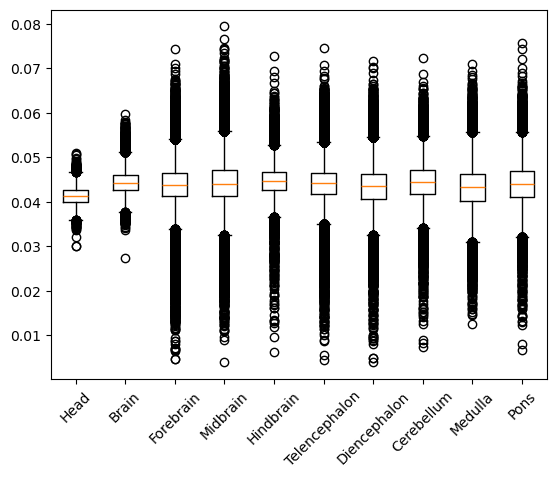

In [99]:
data_all=[]
regions_up=[]
regions=["b'Head'","b'Brain'","b'Forebrain'","b'Midbrain'", "b'Hindbrain'","b'Telencephalon'","b'Diencephalon'","b'Cerebellum'",
 "b'Medulla'","b'Pons'"]
for region in regions:
    r=region[2:-1]
    data_region=adata.obs.loc[adata.obs.Region==region,'per_cell_exp_har']
    data_all.append(data_region)
    regions_up.append(r)

plt2.boxplot(data_all, labels=regions_up)
plt2.xticks(rotation=45)

In [108]:
adata.obs.Region

CellID
b'10X89_1:ACGAGGAAGAGCCTAG'     b'Telencephalon'
b'10X89_1:ACGCCAGTCGATAGAA'     b'Telencephalon'
b'10X89_1:CTTCTCTAGTCAAGGC'     b'Telencephalon'
b'10X89_1:GGGCACTAGCGATATA'     b'Telencephalon'
b'10X89_1:TTCTACAAGGTGTGGT'     b'Telencephalon'
                                      ...       
b'10X302_7:AGAGAATAGAGGATCC'         b'Midbrain'
b'10X302_8:AAGCCATTCCACCTCA'         b'Midbrain'
b'10X302_8:ACGGTTAGTTAGGCCC'         b'Midbrain'
b'10X302_8:CATGCCTCAACCCGCA'         b'Midbrain'
b'10X302_8:CCTTTGGCAACGATTC'         b'Midbrain'
Name: Region, Length: 1655848, dtype: category
Categories (10, object): ['b'Brain'', 'b'Cerebellum'', 'b'Diencephalon'', 'b'Forebrain'', ..., 'b'Medulla'', 'b'Midbrain'', 'b'Pons'', 'b'Telencephalon'']

/tmp/ipykernel_1007100/487469431.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt2.boxplot(data_all, labels=regions_up)


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(1, 0, 'Head'),
  Text(2, 0, 'Brain'),
  Text(3, 0, 'Forebrain'),
  Text(4, 0, 'Midbrain'),
  Text(5, 0, 'Hindbrain'),
  Text(6, 0, 'Telencephalon'),
  Text(7, 0, 'Diencephalon'),
  Text(8, 0, 'Cerebellum'),
  Text(9, 0, 'Medulla'),
  Text(10, 0, 'Pons')])

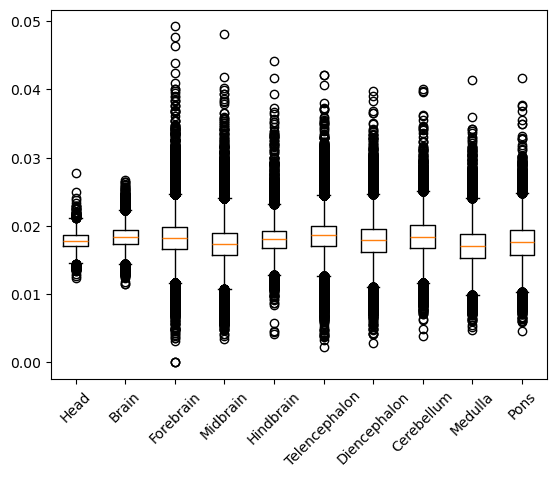

In [100]:
data_all=[]
regions_up=[]
for region in regions:
    r=region[2:-1]
    data_region=adata.obs.loc[adata.obs.Region==region,'per_cell_exp_hsg']
    data_all.append(data_region)
    regions_up.append(r)
plt2.boxplot(data_all, labels=regions_up)
plt2.xticks(rotation=45)

In [22]:
adata.obs.CellClass.unique().tolist()

["b'Erythrocyte'",
 "b'Fibroblast'",
 "b'Glioblast'",
 "b'Immune'",
 "b'Neuroblast'",
 "b'Neural crest'",
 "b'Neuron'",
 "b'Neuronal IPC'",
 "b'Oligo'",
 "b'Radial glia'",
 "b'Placodes'",
 "b'Vascular'"]

/tmp/ipykernel_1007100/447645538.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt2.boxplot(data_all, labels=ct_up)


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(1, 0, 'Erythrocyte'),
  Text(2, 0, 'Fibroblast'),
  Text(3, 0, 'Immune'),
  Text(4, 0, 'Placodes'),
  Text(5, 0, 'Vascular'),
  Text(6, 0, 'Neural crest'),
  Text(7, 0, 'Glioblast'),
  Text(8, 0, 'Oligo'),
  Text(9, 0, 'Radial glia'),
  Text(10, 0, 'Neuronal IPC'),
  Text(11, 0, 'Neuroblast'),
  Text(12, 0, 'Neuron')])

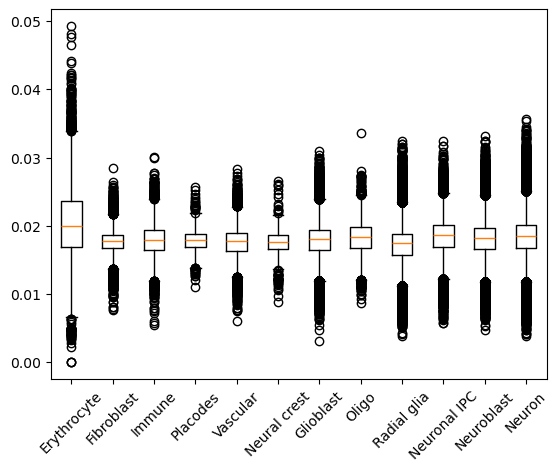

In [39]:
data_all=[]
data_all_todf=[]
cell_types_list=[]
ct_up=[]
#celltypes=adata.obs.CellClass.unique().tolist()
celltypes=["b'Erythrocyte'", "b'Fibroblast'","b'Immune'","b'Placodes'","b'Vascular'", "b'Neural crest'", "b'Glioblast'", "b'Oligo'",
         "b'Radial glia'","b'Neuronal IPC'", "b'Neuroblast'","b'Neuron'" ]
for celltype in celltypes:
    ct=celltype[2:-1]
    data_ct=adata.obs.loc[adata.obs.CellClass==celltype,'per_cell_exp_hsg']
    data_all.append(data_ct)
    data_all_todf.extend(data_ct)
    cell_types_list.extend([ct]*len(data_ct))
    ct_up.append(ct)

data_df=pd.DataFrame({'cell_types':cell_types_list,'per_hsg':data_all_todf})
plt2.boxplot(data_all, labels=ct_up)
plt2.xticks(rotation=45)

In [ ]:
## anova and post hok testing..

In [40]:
from scipy.stats import f_oneway

In [52]:
cts=['Erythrocyte', 'Fibroblast','Immune','Placodes','Vascular', 'Neural crest', 'Glioblast', 'Oligo',
         'Radial glia','Neuronal IPC', 'Neuroblast','Neuron']
groups=[list(data_df.loc[data_df['cell_types']== ct,'per_hsg']) for ct in cts]
f_oneway(*groups)

F_onewayResult(statistic=np.float64(6353.973003548701), pvalue=np.float64(0.0))

In [54]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [57]:
tukey_results=pairwise_tukeyhsd(data_df["per_hsg"],data_df["cell_types"],alpha=0.05)
print(tukey_results)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
 Erythrocyte   Fibroblast  -0.0027    0.0 -0.0029 -0.0026   True
 Erythrocyte    Glioblast  -0.0025    0.0 -0.0026 -0.0024   True
 Erythrocyte       Immune  -0.0025    0.0 -0.0026 -0.0024   True
 Erythrocyte Neural crest  -0.0029    0.0 -0.0032 -0.0026   True
 Erythrocyte   Neuroblast  -0.0023    0.0 -0.0024 -0.0022   True
 Erythrocyte       Neuron   -0.002    0.0 -0.0021 -0.0018   True
 Erythrocyte Neuronal IPC   -0.002    0.0 -0.0021 -0.0019   True
 Erythrocyte        Oligo  -0.0021    0.0 -0.0023  -0.002   True
 Erythrocyte     Placodes  -0.0025    0.0 -0.0028 -0.0022   True
 Erythrocyte  Radial glia  -0.0031    0.0 -0.0032  -0.003   True
 Erythrocyte     Vascular  -0.0028    0.0 -0.0029 -0.0027   True
  Fibroblast    Glioblast   0.0002    0.0  0.0002  0.0003   True
  Fibroblast       Immune

/tmp/ipykernel_1007100/898542264.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt2.boxplot(data_all, labels=ct_up)


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(1, 0, 'Erythrocyte'),
  Text(2, 0, 'Fibroblast'),
  Text(3, 0, 'Immune'),
  Text(4, 0, 'Placodes'),
  Text(5, 0, 'Vascular'),
  Text(6, 0, 'Neural crest'),
  Text(7, 0, 'Glioblast'),
  Text(8, 0, 'Oligo'),
  Text(9, 0, 'Radial glia'),
  Text(10, 0, 'Neuronal IPC'),
  Text(11, 0, 'Neuroblast'),
  Text(12, 0, 'Neuron')])

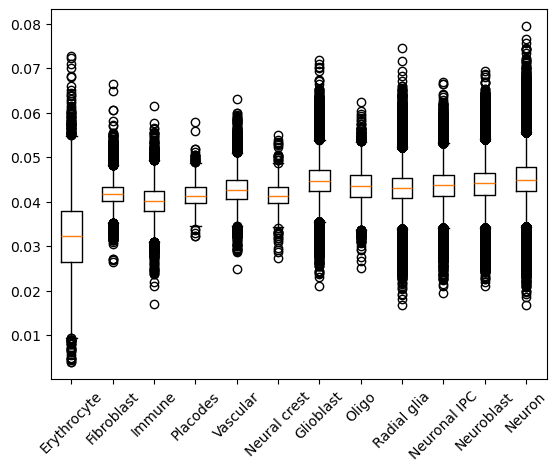

In [58]:
data_all=[]
ct_up=[]
for celltype in celltypes:
    ct=celltype[2:-1]
    data_ct=adata.obs.loc[adata.obs.CellClass==celltype,'per_cell_exp_har']
    data_all.append(data_ct)
    ct_up.append(ct)
plt2.boxplot(data_all, labels=ct_up)
plt2.xticks(rotation=45)
#order it 
#think abput statustical tests

In [90]:
# general expression details and tissue, lets go:

def find_exp_genes(hsg_list,adata):
    genes=hsg_list["gene"].tolist()
    genes_to_check=[]
    for gene in genes:
        gene_exp=np.count_nonzero(adata.X[:,adata.var["Gene"]==gene].toarray().flatten())
        if gene_exp>100:
            print(gene, gene_exp)
            genes_to_check.append(gene)
    return genes_to_check
    
def create_exp_table(gene_list,adata):
    exp={}
    Tissues=adata.obs.Tissue.unique().tolist()
    Cell_types= adata.obs.CellClass.unique().tolist()
    for t in Tissues:
        print("tissue: ",t)
        relevant_data=adata[adata.obs.Tissue==t,adata.var["Gene"].isin(gene_list)]
        print(relevant_data)
        tissue_name=t[2:-1]
        tissue_name=tissue_name.replace(" ","_")
        for ct in Cell_types:
            print("cell type: ",ct)
            cell_type_name=ct[2:-1]
            cell_type_name=cell_type_name.replace(" ","_")
            num_cells=sum(relevant_data.obs.CellClass==ct)
            print(num_cells)
            if num_cells>100:
                exp[f'per_exp_{tissue_name}_{cell_type_name}']=(relevant_data.X[relevant_data.obs.CellClass==ct,:]>0).mean(axis=0).A1
                print('yay')
                exp[f'mean_exp_{tissue_name}_{cell_type_name}']=relevant_data.X[relevant_data.obs.CellClass==ct,:].mean(axis=0).A1
                print('yay again')
    
    exp_df=pd.DataFrame.from_dict(exp)
    exp_df["gene"]=adata.var["Gene"][adata.var["Gene"].isin(gene_list)].tolist()

    return exp_df

def create_exp_table_one_cond(gene_list,adata,cond):
    exp={}
    if cond=='CellClass':
        Cell_types= adata.obs.CellClass.unique().tolist()
        for ct in Cell_types:
            print("cell type: ",ct)
            relevant_data=adata[adata.obs.CellClass==ct,adata.var["Gene"].isin(gene_list)]
            cell_type_name=ct[2:-1]
            cell_type_name=cell_type_name.replace(" ","_")
            num_cells=sum(relevant_data.obs.CellClass==ct)
            print(num_cells)
            if num_cells>100:
                exp[f'per_exp_{cell_type_name}']=(relevant_data.X>0).mean(axis=0).A1
                print('yay')
                exp[f'mean_exp_{cell_type_name}']=relevant_data.X.mean(axis=0).A1
                print('yay again')
    elif cond=='Tissue':
        Tissues=adata.obs.Tissue.unique().tolist()
        for t in Tissues:
            print("tissue: ",t)
            relevant_data=adata[adata.obs.Tissue==t,adata.var["Gene"].isin(gene_list)]
            tissue_name=t[2:-1]
            tissue_name=tissue_name.replace(" ","_")
            num_cells=sum(relevant_data.obs.Tissue==t)
            print(num_cells)
            if num_cells>100:
                exp[f'per_exp_{tissue_name}']=(relevant_data.X>0).mean(axis=0).A1
                print('yay')
                exp[f'mean_exp_{tissue_name}']=relevant_data.X.mean(axis=0).A1
                print('yay again')
    elif cond=='Region':
        print("wow")
        Regions=adata.obs.Region.unique().tolist()
        for r in Regions:
            print("region: ",r)
            relevant_data=adata[adata.obs.Region==r,adata.var["Gene"].isin(gene_list)]
            tissue_name=r[2:-1]
            tissue_name=tissue_name.replace(" ","_")
            num_cells=sum(relevant_data.obs.Region==r)
            print(num_cells)
            if num_cells>100:
                exp[f'per_exp_{tissue_name}']=(relevant_data.X>0).mean(axis=0).A1
                print('yay')
                exp[f'mean_exp_{tissue_name}']=relevant_data.X.mean(axis=0).A1
                print('yay again')
    exp_df=pd.DataFrame.from_dict(exp)
    exp_df["gene"]=adata.var["Gene"][adata.var["Gene"].isin(gene_list)].tolist()

    return exp_df

def create_exp_table_one_cond_har(gene_list,adata,cond):
    exp={}
    if cond=='CellClass':
        Cell_types= adata.obs.CellClass.unique().tolist()
        for ct in Cell_types:
            print("cell type: ",ct)
            relevant_data=adata[adata.obs.CellClass==ct,adata.var_names.isin(gene_list)]
            cell_type_name=ct[2:-1]
            cell_type_name=cell_type_name.replace(" ","_")
            num_cells=sum(relevant_data.obs.CellClass==ct)
            print(num_cells)
            if num_cells>100:
                exp[f'per_exp_{cell_type_name}']=(relevant_data.X>0).mean(axis=0).A1
                print('yay')
                exp[f'mean_exp_{cell_type_name}']=relevant_data.X.mean(axis=0).A1
                print('yay again')
    elif cond=='Tissue':
        Tissues=adata.obs.Tissue.unique().tolist()
        for t in Tissues:
            print("tissue: ",t)
            relevant_data=adata[adata.obs.Tissue==t,adata.var_names.isin(gene_list)]
            tissue_name=t[2:-1]
            tissue_name=tissue_name.replace(" ","_")
            num_cells=sum(relevant_data.obs.Tissue==t)
            print(num_cells)
            if num_cells>100:
                exp[f'per_exp_{tissue_name}']=(relevant_data.X>0).mean(axis=0).A1
                print('yay')
                exp[f'mean_exp_{tissue_name}']=relevant_data.X.mean(axis=0).A1
                print('yay again')
    elif cond=='Region':
        print("wow")
        Regions=adata.obs.Region.unique().tolist()
        for r in Regions:
            print("region: ",r)
            relevant_data=adata[adata.obs.Region==r,adata.var_names.isin(gene_list)]
            tissue_name=r[2:-1]
            tissue_name=tissue_name.replace(" ","_")
            num_cells=sum(relevant_data.obs.Region==r)
            print(num_cells)
            if num_cells>100:
                exp[f'per_exp_{tissue_name}']=(relevant_data.X>0).mean(axis=0).A1
                print('yay')
                exp[f'mean_exp_{tissue_name}']=relevant_data.X.mean(axis=0).A1
                print('yay again')
    exp_df=pd.DataFrame.from_dict(exp)
    exp_df["ens"]=adata.var_names[adata.var_names.isin(gene_list)].tolist()

    return exp_df


In [35]:
exp_gene_list=find_exp_genes(hsg,adata)

AATBC 1431
ABCB10 163874
ABCC12 1788
ABCC6 14401
ABCD4 402549
ABHD17A 212423
AC062028.1 3053
ACTR3B 345808
ADARB1 201390
ADORA2A-AS1 15849
AFF3 829407
AGR3 1550
AHRR 10825
AL592528.1 2707
ALOX5 10286
AMY1A 116
AMY2B 69049
ANAPC1 197023
ANKRD20A2 4392
ANKRD20A4 53300
ANKRD30A 2448
APEH 212530
APOL1 1093
APPBP2 578166
AQP7 500
AR 122948
AREG 1924
ARHGAP11B 979
ARHGAP15 54878
ARHGAP42 162039
ASPM 251349
ATP9B 479894
BAZ2A 303784
BMPR1A 594042
BOLA2 428
BOLL 6559
BTNL2 6089
C11orf80 415731
C1orf229 9839
C1orf61 1023939
C20orf203 2049
C21orf62-AS1 69089
C2orf78 188
C3orf36 109
CAPN1 238408
CATSPER2 115515
CBWD2 250204
CBWD3 41394
CBWD5 181099
CCDC127 272618
CCDC74B 68692
CCKAR 1699
CCZ1B 275328
CD24 1360474
CD44 35439
CDH12 346357
CDK5RAP2 455792
CELSR2 338626
CEP170 966172
CFAP99 6652
CFC1 10022
CHRFAM7A 7886
CHRM3 113602
CLEC10A 209
CLTCL1 100981
CNTNAP2 923466
COMMD4 421250
COPS7B 315622
CRHR1 494
CROCC 381265
CSPG4 14836
CXorf40A 69371
DDR2 47294
DDX11 141215
DDX54 240685
DGCR6L 437979


In [75]:
#also for har
#based on cortex data, not perfect but fine for now
har_exp=pd.read_csv("/scratch200/reutj/data/hsg_gene_lists/har_exp_in_adata_cortex2.csv")
har_exp_list=list(har_exp.loc[har_exp.num_cells_expressed>100,'ens'])

In [ ]:
enr = gp.enrichr(gene_list=har_exp_list, # or "./tests/data/gene_list.txt",
                 gene_sets=['MSigDB_Hallmark_2020','KEGG_2021_Human'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [247]:
for i in har_exp_list:
    print(i)

ENSG00000002822
ENSG00000004897
ENSG00000005020
ENSG00000009724
ENSG00000011105
ENSG00000013561
ENSG00000013810
ENSG00000014164
ENSG00000015285
ENSG00000023191
ENSG00000028277
ENSG00000029725
ENSG00000043462
ENSG00000044115
ENSG00000044446
ENSG00000051596
ENSG00000054282
ENSG00000054598
ENSG00000060237
ENSG00000062716
ENSG00000063438
ENSG00000064419
ENSG00000064999
ENSG00000065413
ENSG00000066027
ENSG00000066230
ENSG00000066405
ENSG00000066735
ENSG00000067225
ENSG00000067900
ENSG00000068394
ENSG00000069869
ENSG00000070366
ENSG00000070748
ENSG00000071909
ENSG00000072182
ENSG00000072195
ENSG00000072518
ENSG00000072609
ENSG00000073578
ENSG00000074047
ENSG00000074695
ENSG00000075884
ENSG00000077097
ENSG00000077157
ENSG00000078098
ENSG00000079337
ENSG00000080503
ENSG00000081791
ENSG00000086717
ENSG00000087995
ENSG00000088280
ENSG00000088356
ENSG00000089116
ENSG00000089682
ENSG00000089902
ENSG00000090273
ENSG00000090612
ENSG00000091656
ENSG00000091844
ENSG00000092054
ENSG00000095587
ENSG0000

In [67]:
exp_df=create_exp_table(exp_gene_list,adata)

tissue:  b'Cortex'
View of AnnData object with n_obs × n_vars = 149628 × 416
    obs: 'Age', 'CellClass', 'Region', 'Subdivision', 'Subregion', 'Tissue', 'TopLevelCluster', 'organism_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'sample_id', 'cluster_id', 'n_genes'
    var: 'Chromosome', 'End', 'Gene', 'Start', 'Strand', 'n_cells'
    uns: 'batch_condition', 'schema_version', 'title'
    layers: 'ambiguous', 'spliced', 'unspliced'
cell type:  b'Erythrocyte'
366
yay
yay again
cell type:  b'Fibroblast'
17
cell type:  b'Glioblast'
8960
yay
yay again
cell type:  b'Immune'
484
yay
yay again
cell type:  b'Neuroblast'
29398
yay
yay again
cell type:  b'Neural crest'
4
cell type:  b'Neuron'
37749
yay
yay again
cell type:  b'Neuronal IPC'
12899
yay
yay again
cell type:  b'Oligo'
156
yay
yay again
cell type:  b'Radial gli

In [68]:
exp_df

,per_exp_Cortex_Erythrocyte,mean_exp_Cortex_Erythrocyte,per_exp_Cortex_Glioblast,mean_exp_Cortex_Glioblast,per_exp_Cortex_Immune,mean_exp_Cortex_Immune,per_exp_Cortex_Neuroblast,mean_exp_Cortex_Neuroblast,per_exp_Cortex_Neuron,mean_exp_Cortex_Neuron,...,mean_exp_Midbrain_Neuroblast,per_exp_Midbrain_Neuron,mean_exp_Midbrain_Neuron,per_exp_Midbrain_Neuronal_IPC,mean_exp_Midbrain_Neuronal_IPC,per_exp_Midbrain_Radial_glia,mean_exp_Midbrain_Radial_glia,per_exp_Midbrain_Vascular,mean_exp_Midbrain_Vascular,gene
0,0.000000,0.000000,0.000112,0.000112,0.000000,0.000000,0.000646,0.000646,0.000927,0.001007,...,0.000791,0.000868,0.000868,0.000000,0.000000,0.000620,0.000620,0.000000,0.000000,TNFRSF9
1,0.005464,0.005464,0.158482,0.189955,0.090909,0.099174,0.101231,0.114532,0.137328,0.160216,...,0.147640,0.142155,0.162979,0.098196,0.124248,0.146919,0.180469,0.081081,0.081081,NBPF1
2,0.030055,0.030055,0.314844,0.489286,0.299587,0.444215,0.205932,0.280563,0.206204,0.276140,...,0.396784,0.318004,0.500506,0.196393,0.286573,0.274297,0.421785,0.292793,0.472973,KIAA0319L
3,0.000000,0.000000,0.066406,0.078237,0.002066,0.002066,0.026532,0.031295,0.040690,0.050094,...,0.132085,0.139407,0.191034,0.096192,0.130261,0.059502,0.074804,0.013514,0.018018,RAB3B
4,0.000000,0.000000,0.003125,0.003125,0.002066,0.002066,0.022757,0.031159,0.132957,0.195105,...,0.599789,0.255098,0.558930,0.270541,0.583166,0.014682,0.021350,0.000000,0.000000,MIR137HG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,0.000000,0.000000,0.009933,0.010937,0.000000,0.000000,0.004796,0.005715,0.006729,0.008239,...,0.008173,0.008388,0.010123,0.000000,0.000000,0.004084,0.004446,0.000000,0.000000,SPANXA2-OT1
412,0.005464,0.005464,0.032478,0.033036,0.014463,0.016529,0.052078,0.053609,0.060929,0.063445,...,0.035856,0.042372,0.044396,0.020040,0.020040,0.033447,0.034636,0.058559,0.058559,CXorf40A
413,0.000000,0.000000,0.012723,0.013393,0.002066,0.002066,0.015171,0.016430,0.022146,0.024372,...,0.018719,0.029790,0.032393,0.014028,0.014028,0.012924,0.014682,0.031532,0.040541,SPRY3
414,0.032787,0.032787,0.103460,0.116853,0.183884,0.219008,0.074461,0.080414,0.087102,0.094413,...,0.102557,0.100217,0.120029,0.070140,0.076152,0.105718,0.128774,0.148649,0.189189,VAMP7


In [88]:
exp_df.to_csv("/scratch200/reutj/data/exp_df_tissue_celltype_alldata.csv")

In [75]:
#exp_df=pd.read_csv("/scratch200/reutj/data/exp_df_tissue_celltype_alldata.csv")

In [76]:
exp_gene_list=exp_df["gene"].to_list()

In [77]:
exp_df_region=create_exp_table_one_cond(exp_gene_list,adata,'Region')

wow
tissue:  b'Telencephalon'
379181
yay
yay again
tissue:  b'Diencephalon'
190365
yay
yay again
tissue:  b'Midbrain'
255163
yay
yay again
tissue:  b'Forebrain'
311939
yay
yay again
tissue:  b'Cerebellum'
142128
yay
yay again
tissue:  b'Medulla'
126659
yay
yay again
tissue:  b'Pons'
94906
yay
yay again
tissue:  b'Hindbrain'
62777
yay
yay again
tissue:  b'Head'
6733
yay
yay again
tissue:  b'Brain'
85997
yay
yay again


In [78]:
exp_df_region

,per_exp_Telencephalon,mean_exp_Telencephalon,per_exp_Diencephalon,mean_exp_Diencephalon,per_exp_Midbrain,mean_exp_Midbrain,per_exp_Forebrain,mean_exp_Forebrain,per_exp_Cerebellum,mean_exp_Cerebellum,...,mean_exp_Medulla,per_exp_Pons,mean_exp_Pons,per_exp_Hindbrain,mean_exp_Hindbrain,per_exp_Head,mean_exp_Head,per_exp_Brain,mean_exp_Brain,gene
0,0.000527,0.000554,0.000452,0.000483,0.000455,0.000490,0.000343,0.000365,0.000584,0.000704,...,0.000253,0.000263,0.000295,0.000637,0.000669,0.006981,0.009802,0.001279,0.001407,TNFRSF9
1,0.154314,0.188794,0.096846,0.110672,0.103585,0.120049,0.129295,0.156790,0.164380,0.201874,...,0.088924,0.072282,0.079300,0.156060,0.188939,0.216545,0.256498,0.216054,0.267684,NBPF1
2,0.249767,0.367529,0.184209,0.244583,0.219209,0.305413,0.217450,0.307627,0.226205,0.304690,...,0.168689,0.160201,0.192759,0.343454,0.513723,0.446161,0.713946,0.478784,0.823796,KIAA0319L
3,0.066530,0.086856,0.061130,0.077378,0.038854,0.050352,0.061836,0.082535,0.099052,0.139501,...,0.127571,0.065096,0.086570,0.205617,0.372875,0.176147,0.276400,0.258451,0.488889,RAB3B
4,0.075639,0.136125,0.146807,0.299341,0.053358,0.085753,0.106322,0.202062,0.022459,0.029030,...,0.043021,0.040703,0.052747,0.126464,0.255619,0.045002,0.154018,0.263998,0.779155,MIR137HG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,0.005784,0.006965,0.003063,0.003372,0.003519,0.004099,0.003485,0.004129,0.004721,0.005544,...,0.001871,0.002708,0.002877,0.006722,0.008172,0.006535,0.007278,0.008919,0.010779,SPANXA2-OT1
412,0.046231,0.048056,0.028283,0.029091,0.035358,0.036526,0.039396,0.040758,0.048330,0.049828,...,0.039484,0.031652,0.032348,0.058254,0.060994,0.086737,0.092232,0.071526,0.074677,CXorf40A
413,0.020808,0.022654,0.007743,0.008079,0.010973,0.011781,0.012044,0.012810,0.018589,0.019820,...,0.006490,0.008440,0.008661,0.019737,0.021505,0.017823,0.018565,0.033117,0.036676,SPRY3
414,0.085574,0.096885,0.077309,0.084727,0.085189,0.095609,0.086405,0.096958,0.082271,0.090686,...,0.063856,0.060007,0.064011,0.117814,0.136117,0.236150,0.286796,0.185530,0.224578,VAMP7


In [79]:
exp_df_region.to_csv("/scratch200/reutj/data/exp_df_region_alldata.csv")

In [181]:
exp_df_region=pd.read_csv("/scratch200/reutj/data/exp_df_region_alldata.csv")

In [82]:
region_names=[i[2:-1] for i in regions]

/tmp/ipykernel_1008464/3693534194.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt2.boxplot(exp_df_region_hsg.loc[:,['per_exp_Head','per_exp_Brain','per_exp_Forebrain','per_exp_Midbrain','per_exp_Hindbrain',


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(1, 0, 'Head'),
  Text(2, 0, 'Brain'),
  Text(3, 0, 'Forebrain'),
  Text(4, 0, 'Midbrain'),
  Text(5, 0, 'Hindbrain'),
  Text(6, 0, 'Telencephalon'),
  Text(7, 0, 'Diencephalon'),
  Text(8, 0, 'Pons'),
  Text(9, 0, 'Cerebellum'),
  Text(10, 0, 'Medulla')])

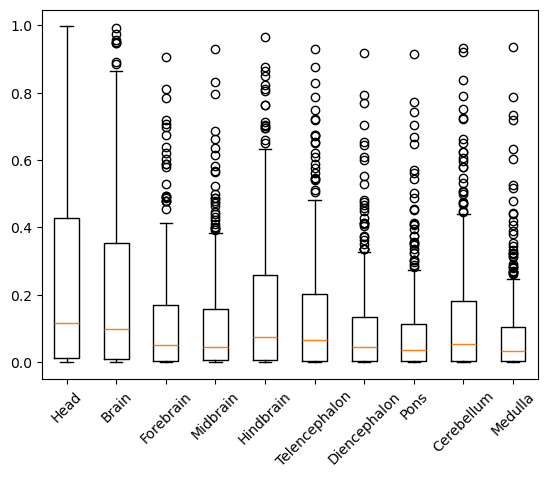

In [91]:
exp_df_region_hsg=exp_df_region.loc[exp_df_region.gene.isin(gene_exp_list),:]
plt2.boxplot(exp_df_region_hsg.loc[:,['per_exp_Head','per_exp_Brain','per_exp_Forebrain','per_exp_Midbrain','per_exp_Hindbrain',
                                       'per_exp_Telencephalon','per_exp_Diencephalon','per_exp_Pons','per_exp_Cerebellum','per_exp_Medulla']],
             labels=['Head','Brain','Forebrain','Midbrain','Hindbrain','Telencephalon','Diencephalon','Pons','Cerebellum','Medulla'])
plt2.xticks(rotation=45)

In [ ]:
adata.obs[ada

/tmp/ipykernel_1008464/4125357388.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt2.boxplot(exp_df_region_hsg.loc[:,['mean_exp_Head','mean_exp_Brain','mean_exp_Forebrain','mean_exp_Midbrain','mean_exp_Hindbrain',


(0.0, 5.0)

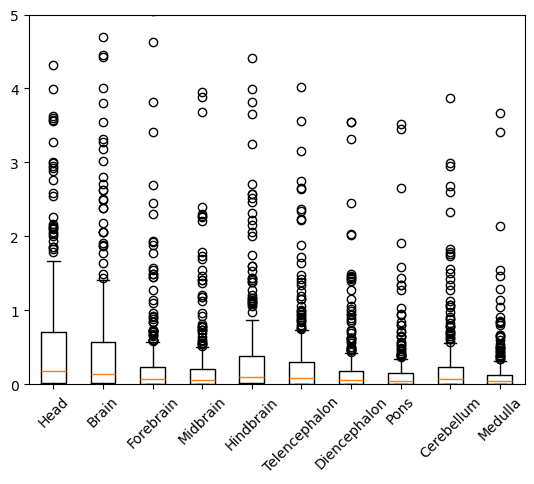

In [95]:
plt2.boxplot(exp_df_region_hsg.loc[:,['mean_exp_Head','mean_exp_Brain','mean_exp_Forebrain','mean_exp_Midbrain','mean_exp_Hindbrain',
                                       'mean_exp_Telencephalon','mean_exp_Diencephalon','mean_exp_Pons','mean_exp_Cerebellum','mean_exp_Medulla']],
             labels=['Head','Brain','Forebrain','Midbrain','Hindbrain','Telencephalon','Diencephalon','Pons','Cerebellum','Medulla'])
plt2.xticks(rotation=45)
plt2.ylim(0,5)

In [91]:
exp_df_region_har=create_exp_table_one_cond_har(har_exp_list,adata,'Region')

wow
region:  b'Telencephalon'
379181
yay
yay again
region:  b'Diencephalon'
190365
yay
yay again
region:  b'Midbrain'
255163
yay
yay again
region:  b'Forebrain'
311939
yay
yay again
region:  b'Cerebellum'
142128
yay
yay again
region:  b'Medulla'
126659
yay
yay again
region:  b'Pons'
94906
yay
yay again
region:  b'Hindbrain'
62777
yay
yay again
region:  b'Head'
6733
yay
yay again
region:  b'Brain'
85997
yay
yay again


In [203]:
exp_df_region_har.to_csv("/scratch200/reutj/data/exp_byregion_har.csv")

/tmp/ipykernel_1007100/1553939658.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt2.boxplot(exp_df_region_har.loc[:,['per_exp_Head','per_exp_Brain','per_exp_Forebrain','per_exp_Midbrain','per_exp_Hindbrain',


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(1, 0, 'Head'),
  Text(2, 0, 'Brain'),
  Text(3, 0, 'Forebrain'),
  Text(4, 0, 'Midbrain'),
  Text(5, 0, 'Hindbrain'),
  Text(6, 0, 'Telencephalon'),
  Text(7, 0, 'Diencephalon'),
  Text(8, 0, 'Pons'),
  Text(9, 0, 'Cerebellum'),
  Text(10, 0, 'Medulla')])

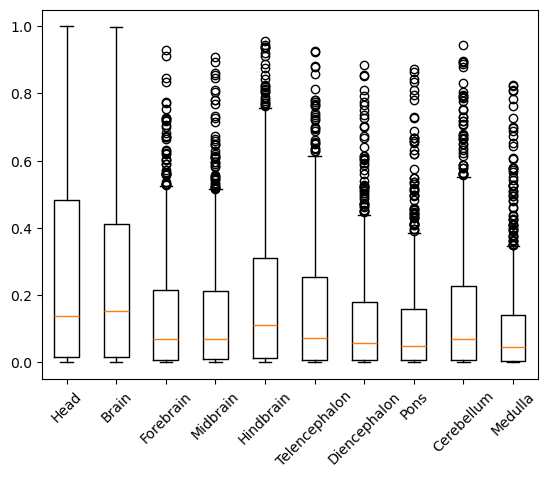

In [95]:
plt2.boxplot(exp_df_region_har.loc[:,['per_exp_Head','per_exp_Brain','per_exp_Forebrain','per_exp_Midbrain','per_exp_Hindbrain',
                                       'per_exp_Telencephalon','per_exp_Diencephalon','per_exp_Pons','per_exp_Cerebellum','per_exp_Medulla']],
             labels=['Head','Brain','Forebrain','Midbrain','Hindbrain','Telencephalon','Diencephalon','Pons','Cerebellum','Medulla'])
plt2.xticks(rotation=45)

/tmp/ipykernel_1007100/3062799958.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt2.boxplot(exp_df_region_har.loc[:,['mean_exp_Head','mean_exp_Brain','mean_exp_Forebrain','mean_exp_Midbrain','mean_exp_Hindbrain',


(0.0, 5.0)

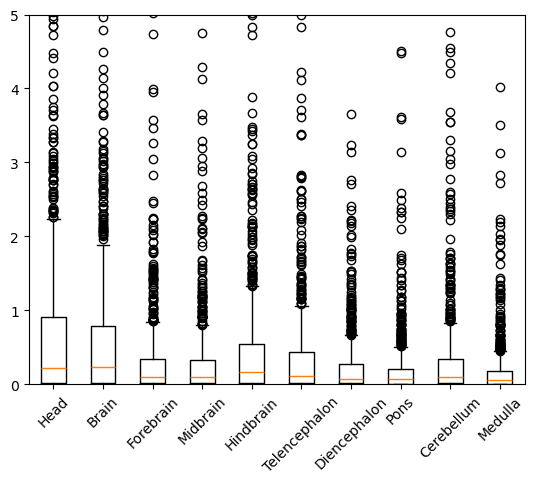

In [94]:
plt2.boxplot(exp_df_region_har.loc[:,['mean_exp_Head','mean_exp_Brain','mean_exp_Forebrain','mean_exp_Midbrain','mean_exp_Hindbrain',
                                       'mean_exp_Telencephalon','mean_exp_Diencephalon','mean_exp_Pons','mean_exp_Cerebellum','mean_exp_Medulla']],
             labels=['Head','Brain','Forebrain','Midbrain','Hindbrain','Telencephalon','Diencephalon','Pons','Cerebellum','Medulla'])
plt2.xticks(rotation=45)
plt2.ylim(0,5)

In [ ]:
## tissue

In [82]:
exp_df_tissue=create_exp_table_one_cond(exp_gene_list,adata,'Tissue')

tissue:  b'Cortex'
149628
yay
yay again
tissue:  b'Hypothalamus'
46159
yay
yay again
tissue:  b'Thalamus'
109641
yay
yay again
tissue:  b'Ventral midbrain'
16396
yay
yay again
tissue:  b'Forebrain cortex'
14866
yay
yay again
tissue:  b'Subcortical forebrain'
53730
yay
yay again
tissue:  b'Forebrain'
193526
yay
yay again
tissue:  b'Cerebellum'
142128
yay
yay again
tissue:  b'Dorsal midbrain'
42918
yay
yay again
tissue:  b'Medulla'
126659
yay
yay again
tissue:  b'Mesencephalon'
162383
yay
yay again
tissue:  b'Pons/Cereb'
33373
yay
yay again
tissue:  b'Tel/diencephalon'
16795
yay
yay again
tissue:  b'Diencephalon'
34565
yay
yay again
tissue:  b'Pons'
61533
yay
yay again
tissue:  b'Striatum'
94538
yay
yay again
tissue:  b'Telencephalon'
7052
yay
yay again
tissue:  b'Hindbrain'
49284
yay
yay again
tissue:  b'Head'
6733
yay
yay again
tissue:  b'Pons/Medulla'
13493
yay
yay again
tissue:  b'Subcortex'
28423
yay
yay again
tissue:  b'Enthorinal cortex'
10836
yay
yay again
tissue:  b'Hippocampus'

In [89]:
exp_df_tissue

,per_exp_Cortex,mean_exp_Cortex,per_exp_Hypothalamus,mean_exp_Hypothalamus,per_exp_Thalamus,mean_exp_Thalamus,per_exp_Ventral_midbrain,mean_exp_Ventral_midbrain,per_exp_Forebrain_cortex,mean_exp_Forebrain_cortex,...,mean_exp_Occipital_cortex,per_exp_Upper_cortex,mean_exp_Upper_cortex,per_exp_Caudate-Putamen,mean_exp_Caudate-Putamen,per_exp_Brain,mean_exp_Brain,per_exp_Midbrain,mean_exp_Midbrain,gene
0,0.000541,0.000575,0.000325,0.000390,0.000584,0.000611,0.000061,0.000061,0.000269,0.000269,...,0.000750,0.000668,0.000668,0.000531,0.000531,0.001279,0.001407,0.000657,0.000717,TNFRSF9
1,0.121154,0.143369,0.071449,0.078056,0.105590,0.122664,0.038790,0.042144,0.085968,0.092560,...,0.310270,0.266939,0.334026,0.324960,0.458147,0.216054,0.267684,0.137423,0.165212,NBPF1
2,0.213643,0.297003,0.152755,0.189042,0.205042,0.284364,0.111979,0.139851,0.130365,0.148796,...,0.590180,0.440594,0.723711,0.306291,0.520149,0.478784,0.823796,0.276639,0.422190,KIAA0319L
3,0.055117,0.068817,0.044152,0.053034,0.070448,0.091672,0.019334,0.020554,0.032019,0.037064,...,0.084483,0.186494,0.264861,0.064658,0.094483,0.258451,0.488889,0.075211,0.101386,RAB3B
4,0.040634,0.058752,0.077233,0.102515,0.186007,0.414781,0.018480,0.020066,0.057716,0.074398,...,0.109820,0.151243,0.318145,0.182211,0.511725,0.263998,0.779155,0.099116,0.205582,MIR137HG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,0.004144,0.004905,0.002101,0.002426,0.003794,0.004168,0.001464,0.001586,0.001480,0.001547,...,0.011769,0.008609,0.009870,0.007134,0.009259,0.008919,0.010779,0.005169,0.005857,SPANXA2-OT1
412,0.044049,0.045446,0.021426,0.021968,0.030573,0.031521,0.021469,0.022201,0.029194,0.029598,...,0.071139,0.090983,0.096549,0.039159,0.039766,0.071526,0.074677,0.034453,0.035887,CXorf40A
413,0.013981,0.015057,0.006824,0.006998,0.009212,0.009659,0.005123,0.005550,0.006996,0.006996,...,0.051574,0.060037,0.065751,0.027700,0.031570,0.033117,0.036676,0.016405,0.018168,SPRY3
414,0.082645,0.090377,0.054702,0.059143,0.084530,0.093542,0.047268,0.051598,0.047895,0.050652,...,0.153223,0.158219,0.190501,0.090688,0.111179,0.185530,0.224578,0.100430,0.121048,VAMP7


In [86]:
exp_df_tissue.to_csv("/scratch200/reutj/data/exp_df_tissue_alldata.csv")

In [ ]:
# cell class

In [83]:
exp_df_ct=create_exp_table_one_cond(exp_gene_list,adata,'CellClass')

cell type:  b'Erythrocyte'
6510
yay
yay again
cell type:  b'Fibroblast'
19080
yay
yay again
cell type:  b'Glioblast'
131684
yay
yay again
cell type:  b'Immune'
8101
yay
yay again
cell type:  b'Neuroblast'
284218
yay
yay again
cell type:  b'Neural crest'
868
yay
yay again
cell type:  b'Neuron'
558759
yay
yay again
cell type:  b'Neuronal IPC'
109809
yay
yay again
cell type:  b'Oligo'
6175
yay
yay again
cell type:  b'Radial glia'
518030
yay
yay again
cell type:  b'Placodes'
873
yay
yay again
cell type:  b'Vascular'
11741
yay
yay again


In [131]:
exp_df_ct_har=create_exp_table_one_cond_har(har_exp_list,adata,'CellClass')

cell type:  b'Erythrocyte'
6510
yay
yay again
cell type:  b'Fibroblast'
19080
yay
yay again
cell type:  b'Glioblast'
131684
yay
yay again
cell type:  b'Immune'
8101
yay
yay again
cell type:  b'Neuroblast'
284218
yay
yay again
cell type:  b'Neural crest'
868
yay
yay again
cell type:  b'Neuron'
558759
yay
yay again
cell type:  b'Neuronal IPC'
109809
yay
yay again
cell type:  b'Oligo'
6175
yay
yay again
cell type:  b'Radial glia'
518030
yay
yay again
cell type:  b'Placodes'
873
yay
yay again
cell type:  b'Vascular'
11741
yay
yay again


In [87]:
exp_df_ct.to_csv("/scratch200/reutj/data/exp_df_cell_type_alldata.csv")

In [60]:
exp_df_ct=pd.read_csv("/scratch200/reutj/data/exp_df_cell_type_alldata.csv")

In [59]:
exp_df_ct

,Unnamed: 0,per_exp_Erythrocyte,mean_exp_Erythrocyte,per_exp_Fibroblast,mean_exp_Fibroblast,per_exp_Glioblast,mean_exp_Glioblast,per_exp_Immune,mean_exp_Immune,per_exp_Neuroblast,...,mean_exp_Neuronal_IPC,per_exp_Oligo,mean_exp_Oligo,per_exp_Radial_glia,mean_exp_Radial_glia,per_exp_Placodes,mean_exp_Placodes,per_exp_Vascular,mean_exp_Vascular,gene
0,0,0.000154,0.000154,0.001101,0.001258,0.000311,0.000327,0.003333,0.005802,0.000443,...,0.000291,0.000486,0.000486,0.000388,0.000411,0.033219,0.053837,0.002214,0.002385,TNFRSF9
1,1,0.004762,0.004762,0.173532,0.204507,0.147262,0.179513,0.085545,0.097642,0.123060,...,0.206750,0.105101,0.125182,0.121696,0.145084,0.178694,0.213058,0.084490,0.094626,NBPF1
2,2,0.050691,0.061598,0.352358,0.530818,0.311579,0.478297,0.267992,0.391927,0.226865,...,0.313107,0.285020,0.422024,0.228491,0.326987,0.373425,0.719359,0.322375,0.531982,KIAA0319L
3,3,0.003994,0.004147,0.078721,0.103512,0.061617,0.082295,0.005925,0.006049,0.107421,...,0.095712,0.028826,0.034818,0.064012,0.089012,0.293242,0.619702,0.012946,0.016097,RAB3B
4,4,0.004916,0.005069,0.010901,0.013260,0.009667,0.012325,0.004814,0.004814,0.130952,...,0.241884,0.061377,0.084534,0.015700,0.023066,0.245132,1.008018,0.005877,0.006218,MIR137HG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,411,0.000000,0.000000,0.004612,0.005136,0.005726,0.006751,0.000000,0.000000,0.005242,...,0.001794,0.002429,0.002753,0.002471,0.002799,0.002291,0.003436,0.000767,0.000937,SPANXA2-OT1
412,412,0.005069,0.005069,0.058753,0.061740,0.039261,0.040536,0.030243,0.031478,0.049715,...,0.029998,0.034494,0.035304,0.033726,0.034627,0.113402,0.124857,0.073844,0.084916,CXorf40A
413,413,0.000307,0.000307,0.011216,0.011740,0.012781,0.013586,0.002592,0.002592,0.015861,...,0.014416,0.033684,0.037085,0.008328,0.008853,0.035510,0.038946,0.036539,0.039179,SPRY3
414,414,0.039939,0.043011,0.165461,0.195440,0.096845,0.110127,0.160968,0.195161,0.080660,...,0.096149,0.072713,0.082105,0.094357,0.106563,0.184422,0.235968,0.214207,0.278171,VAMP7


In [62]:
gene_exp=pd.read_csv("/scratch200/reutj/data/hsg_gene_lists/hsg_exp_in_adata_cortex2.csv")
gene_exp_list=list(gene_exp.loc[gene_exp.num_cells_expressed>100,'gene'])

In [65]:
cellclasses=[i[2:-1] for i in celltypes]

/tmp/ipykernel_1007100/3919942400.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt2.boxplot(exp_df_ct_hsg.loc[:,['per_exp_Erythrocyte','per_exp_Fibroblast','per_exp_Immune','per_exp_Placodes','per_exp_Vascular'


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(1, 0, 'Erythrocyte'),
  Text(2, 0, 'Fibroblast'),
  Text(3, 0, 'Immune'),
  Text(4, 0, 'Placodes'),
  Text(5, 0, 'Vascular'),
  Text(6, 0, 'Neural crest'),
  Text(7, 0, 'Glioblast'),
  Text(8, 0, 'Oligo'),
  Text(9, 0, 'Radial glia'),
  Text(10, 0, 'Neuronal IPC'),
  Text(11, 0, 'Neuroblast'),
  Text(12, 0, 'Neuron')])

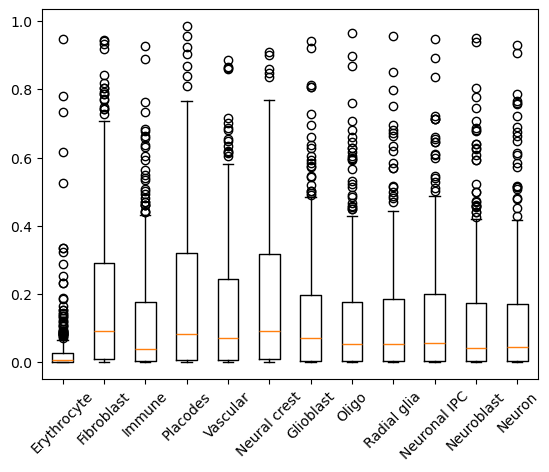

In [68]:
exp_df_ct_hsg=exp_df_ct.loc[exp_df_ct.gene.isin(gene_exp_list),:]
plt2.boxplot(exp_df_ct_hsg.loc[:,['per_exp_Erythrocyte','per_exp_Fibroblast','per_exp_Immune','per_exp_Placodes','per_exp_Vascular'
                                 ,'per_exp_Neural_crest','per_exp_Glioblast','per_exp_Oligo','per_exp_Radial_glia','per_exp_Neuronal_IPC',
                                 'per_exp_Neuroblast','per_exp_Neuron']],labels=cellclasses)
plt2.xticks(rotation=45)


In [ ]:
#tisuue comparison..

In [12]:
tissue=[]
num_exp=[]
mean_per_exp=[]
mean_exp=[]
for i in range(0,exp_df_tissue.shape[1]-1,2):
    tissue.append("_".join(exp_df_tissue.columns[i].split("_")[2:]))
    num_exp.append(sum([j>0.05 for j in exp_df_tissue.iloc[:,i]]))
    mean_per_exp.append(np.mean(exp_df_tissue.iloc[:,i]))
    mean_exp.append(np.mean(exp_df_tissue.iloc[:,i+1]))
tissue_exp=pd.DataFrame({'tissue':tissue,'num_genes_exp':num_exp,'mean_per_exp':mean_per_exp,'mean_exp':mean_exp})
tissue_exp

,tissue,num_genes_exp,mean_per_exp,mean_exp
0,Cortex,183,0.111983,0.250484
1,Hypothalamus,159,0.073526,0.124293
2,Thalamus,184,0.100521,0.206753
3,Ventral_midbrain,140,0.057187,0.103027
4,Forebrain_cortex,147,0.074379,0.132811
5,Subcortical_forebrain,206,0.127418,0.333511
6,Forebrain,175,0.090166,0.174884
7,Cerebellum,194,0.112069,0.253450
8,Dorsal_midbrain,184,0.102316,0.185943
9,Medulla,158,0.073638,0.136699


In [130]:
region=[]
num_exp=[]
mean_per_exp=[]
mean_exp=[]
for i in range(0,exp_df_region.shape[1]-1,2):
    region.append("_".join(exp_df_region.columns[i].split("_")[2:]))
    num_exp.append(sum([j>0.05 for j in exp_df_region.iloc[:,i]]))
    mean_per_exp.append(np.mean(exp_df_region.iloc[:,i]))
    mean_exp.append(np.mean(exp_df_region.iloc[:,i+1]))
tissue_exp=pd.DataFrame({'region':region,'num_genes_exp':num_exp,'mean_per_exp':mean_per_exp,'mean_exp':mean_exp})
tissue_exp

,region,num_genes_exp,mean_per_exp,mean_exp
0,Telencephalon,196,0.121590,0.296014
1,Diencephalon,178,0.090581,0.175199
2,Midbrain,183,0.099087,0.207110
3,Forebrain,190,0.105408,0.227255
4,Cerebellum,194,0.112069,0.253450
5,Medulla,158,0.073638,0.136699
6,Pons,164,0.080219,0.148898
7,Hindbrain,214,0.145172,0.367001
8,Head,219,0.216440,0.606476
9,Brain,220,0.187495,0.512269


In [140]:
#total gene expressed:
sum(((adata.X[adata.obs.Region== "b'Telencephalon'",:]>0).sum(axis=0).A1)>100)

np.int64(25236)

In [142]:
adata.var

,Chromosome,End,Gene,Start,Strand,n_cells
Accession,,,,,,
ENSG00000238009,1,133723,AL627309.1,89295,-,1325
ENSG00000239945,1,91105,AL627309.3,89551,-,339
ENSG00000225880,1,827522,LINC00115,826206,-,18445
ENSG00000230368,1,876903,FAM41C,868071,-,1581
ENSG00000223764,1,921016,AL645608.1,916865,-,3872
...,...,...,...,...,...,...
ENSG00000198692,Y,20593154,EIF1AY,20575725,+,215422
ENSG00000280969,Y,20781032,RPS4Y2,20756164,+,120
ENSG00000235059,Y,22485592,AC008175.1,22438940,+,11


In [152]:
adatab=adata.X[adata.obs.Region== "b'Telencephalon'",:].copy()

In [157]:
sum((adatab[:,adata.var["Gene"].isin(exp_gene_list)]>0).sum(axis=0).A1>100)

np.int64(379)

In [ ]:
#hsg expressed / total gene expressed:
regions_df={'gene':exp_gene_list}
regions=adata.obs.Region.unique().to_list()
adatas=[]
for r in regions:
    print(r)
    adatas.append(adata.X[adata.obs.Region== r,:].copy())

In [164]:
adatas

[<Compressed Sparse Row sparse matrix of dtype 'int16'
 	with 1132927054 stored elements and shape (379181, 32020)>,
 <Compressed Sparse Row sparse matrix of dtype 'int16'
 	with 445469064 stored elements and shape (190365, 32020)>,
 <Compressed Sparse Row sparse matrix of dtype 'int16'
 	with 667660248 stored elements and shape (255163, 32020)>,
 <Compressed Sparse Row sparse matrix of dtype 'int16'
 	with 829396565 stored elements and shape (311939, 32020)>,
 <Compressed Sparse Row sparse matrix of dtype 'int16'
 	with 397792329 stored elements and shape (142128, 32020)>,
 <Compressed Sparse Row sparse matrix of dtype 'int16'
 	with 253747037 stored elements and shape (126659, 32020)>,
 <Compressed Sparse Row sparse matrix of dtype 'int16'
 	with 201443475 stored elements and shape (94906, 32020)>,
 <Compressed Sparse Row sparse matrix of dtype 'int16'
 	with 233042242 stored elements and shape (62777, 32020)>,
 <Compressed Sparse Row sparse matrix of dtype 'int16'
 	with 37093011 st

In [171]:
totals={}
for r in range(len(regions)):
    region=regions[r][2:-1]
    print(region)
    totals[region]=sum(((adatas[r]>0).sum(axis=0).A1)>100)

Telencephalon
Diencephalon
Midbrain
Forebrain
Cerebellum
Medulla
Pons
Hindbrain
Head
Brain


IndexError: list index out of range

In [169]:
for i in exp_gene_list:
    print(i)
    for r in range(len(regions)):
        region=regions[r][2:-1]
        print(region)
        hsg_exp=sum(((adatas[r][:,adata.var["Gene"].isin(exp_gene_list)]>0).sum(axis=0).A1)>100)
        print('yay')#number of hsg genes expressing in above 100 cells
        regions_df[f'norm_exp_reg_{region}']=hsg_exp/totals[region]

regions_df=pd.DataFrame.from_dict(regions_df)
regions_df

TNFRSF9
Telencephalon


KeyboardInterrupt: 

#### since some of the terms are confusiong lets create parent categories:
* Cerebral Cortex/Neocortex:
Cortex,
Forebrain cortex,
Enthorinal cortex,
Cortical hem,
Frontotemporal cortex,
Lower cortex,
Occipital cortex,
Upper cortex
* Subcortical Regions:
Hippocampus,
Striatum,
Caudate-Putamen,
Subcortex,
Subcortical forebrain
* Diencephalon:
Thalamus,
Diencephalon,
Tel/diencephalon
* Midbrain:
Ventral midbrain,
Dorsal midbrain,
Mesencephalon,
Midbrain
* Hindbrain:
Hindbrain,
Cerebellum,
Pons,
Medulla,
Pons/Medulla,
Pons/Cereb

In [ ]:
#celltype

In [52]:
exp_df_ct=pd.read_csv("/scratch200/reutj/data/exp_df_cell_type_alldata.csv")

In [55]:
exp_df_ct=exp_df_ct.drop(columns=['Unnamed: 0'])

In [10]:
exp_df_ct

,Unnamed: 0,per_exp_Erythrocyte,mean_exp_Erythrocyte,per_exp_Fibroblast,mean_exp_Fibroblast,per_exp_Glioblast,mean_exp_Glioblast,per_exp_Immune,mean_exp_Immune,per_exp_Neuroblast,...,mean_exp_Neuronal_IPC,per_exp_Oligo,mean_exp_Oligo,per_exp_Radial_glia,mean_exp_Radial_glia,per_exp_Placodes,mean_exp_Placodes,per_exp_Vascular,mean_exp_Vascular,gene
0,0,0.000154,0.000154,0.001101,0.001258,0.000311,0.000327,0.003333,0.005802,0.000443,...,0.000291,0.000486,0.000486,0.000388,0.000411,0.033219,0.053837,0.002214,0.002385,TNFRSF9
1,1,0.004762,0.004762,0.173532,0.204507,0.147262,0.179513,0.085545,0.097642,0.123060,...,0.206750,0.105101,0.125182,0.121696,0.145084,0.178694,0.213058,0.084490,0.094626,NBPF1
2,2,0.050691,0.061598,0.352358,0.530818,0.311579,0.478297,0.267992,0.391927,0.226865,...,0.313107,0.285020,0.422024,0.228491,0.326987,0.373425,0.719359,0.322375,0.531982,KIAA0319L
3,3,0.003994,0.004147,0.078721,0.103512,0.061617,0.082295,0.005925,0.006049,0.107421,...,0.095712,0.028826,0.034818,0.064012,0.089012,0.293242,0.619702,0.012946,0.016097,RAB3B
4,4,0.004916,0.005069,0.010901,0.013260,0.009667,0.012325,0.004814,0.004814,0.130952,...,0.241884,0.061377,0.084534,0.015700,0.023066,0.245132,1.008018,0.005877,0.006218,MIR137HG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,411,0.000000,0.000000,0.004612,0.005136,0.005726,0.006751,0.000000,0.000000,0.005242,...,0.001794,0.002429,0.002753,0.002471,0.002799,0.002291,0.003436,0.000767,0.000937,SPANXA2-OT1
412,412,0.005069,0.005069,0.058753,0.061740,0.039261,0.040536,0.030243,0.031478,0.049715,...,0.029998,0.034494,0.035304,0.033726,0.034627,0.113402,0.124857,0.073844,0.084916,CXorf40A
413,413,0.000307,0.000307,0.011216,0.011740,0.012781,0.013586,0.002592,0.002592,0.015861,...,0.014416,0.033684,0.037085,0.008328,0.008853,0.035510,0.038946,0.036539,0.039179,SPRY3
414,414,0.039939,0.043011,0.165461,0.195440,0.096845,0.110127,0.160968,0.195161,0.080660,...,0.096149,0.072713,0.082105,0.094357,0.106563,0.184422,0.235968,0.214207,0.278171,VAMP7


In [26]:
exp_df_ct=exp_df_ct.drop(columns=['Unnamed: 0'])

In [13]:
adata.obs.CellClass

CellID
b'10X89_1:ACGAGGAAGAGCCTAG'     b'Erythrocyte'
b'10X89_1:ACGCCAGTCGATAGAA'     b'Erythrocyte'
b'10X89_1:CTTCTCTAGTCAAGGC'     b'Erythrocyte'
b'10X89_1:GGGCACTAGCGATATA'     b'Erythrocyte'
b'10X89_1:TTCTACAAGGTGTGGT'     b'Erythrocyte'
                                     ...      
b'10X302_7:AGAGAATAGAGGATCC'       b'Vascular'
b'10X302_8:AAGCCATTCCACCTCA'       b'Vascular'
b'10X302_8:ACGGTTAGTTAGGCCC'       b'Vascular'
b'10X302_8:CATGCCTCAACCCGCA'       b'Vascular'
b'10X302_8:CCTTTGGCAACGATTC'       b'Vascular'
Name: CellClass, Length: 1655848, dtype: category
Categories (12, object): ['b'Erythrocyte'', 'b'Fibroblast'', 'b'Glioblast'', 'b'Immune'', ..., 'b'Oligo'', 'b'Placodes'', 'b'Radial glia'', 'b'Vascular'']

In [357]:
#get top10 percentile
celltypes=adata.obs.CellClass.unique().tolist()
p90={}
gene_exp={}
for i in celltypes:
    celltype=i[2:-1]
    print(celltype)
    ct_data=adata.X[adata.obs.CellClass==i,:]
    gene_exp[celltype]=genes_expressed_total[adata.obs.CellClass==i,:].sum(axis=0)>0
    p90[celltype]=np.percentile(ct_data[:,gene_exp[celltype]].mean(axis=0).A1,90)

Erythrocyte
Fibroblast
Glioblast
Immune
Neuroblast
Neural crest
Neuron
Neuronal IPC
Oligo
Radial glia
Placodes
Vascular


In [345]:
p90

{'Erythrocyte': np.float64(0.10359447004608426),
 'Fibroblast': np.float64(0.9730398322850345),
 'Glioblast': np.float64(0.5364357097288738),
 'Immune': np.float64(0.6118750771509698),
 'Neuroblast': np.float64(0.42806437312157725),
 'Neural crest': np.float64(1.367511520737322),
 'Neuron': np.float64(0.402311193197881),
 'Neuronal IPC': np.float64(0.5327887513772248),
 'Oligo': np.float64(0.535951417004054),
 'Radial glia': np.float64(0.48739455244019675),
 'Placodes': np.float64(1.3463917525773175),
 'Vascular': np.float64(0.9243676007154255)}

In [123]:
#p90 from before

{'Erythrocyte': np.float64(0.06497695852534603),
 'Fibroblast': np.float64(0.9086373165617749),
 'Glioblast': np.float64(0.5222957990336169),
 'Immune': np.float64(0.5120478953215658),
 'Neuroblast': np.float64(0.4230678563634293),
 'Neural crest': np.float64(1.0552995391705053),
 'Neuron': np.float64(0.3991073074441527),
 'Neuronal IPC': np.float64(0.5133841488400925),
 'Oligo': np.float64(0.44908502024291685),
 'Radial glia': np.float64(0.48337876184872247),
 'Placodes': np.float64(0.9932416953035506),
 'Vascular': np.float64(0.8170087726769283)}

In [40]:
adata.obs.CellClass.unique()

['b'Erythrocyte'', 'b'Fibroblast'', 'b'Glioblast'', 'b'Immune'', 'b'Neuroblast'', ..., 'b'Neuronal IPC'', 'b'Oligo'', 'b'Radial glia'', 'b'Placodes'', 'b'Vascular'']
Length: 12
Categories (12, object): ['b'Erythrocyte'', 'b'Fibroblast'', 'b'Glioblast'', 'b'Immune'', ..., 'b'Oligo'', 'b'Placodes'', 'b'Radial glia'', 'b'Vascular'']

In [218]:
exp_df_ct=exp_df_ct.drop(columns='Unnamed: 0')

In [346]:
top10={}
for i in range(len(celltypes)):
    ind=i*2+1
    for j in exp_df_ct["gene"]:
        ct=celltypes[i][2:-1]
        exp=float(exp_df_ct.iloc[np.where(exp_df_ct["gene"]==j)[0],ind])
        if ct not in top10:
            top10[ct]=[bool(exp>=p90[ct])]
        else:
            top10[ct].append(bool(exp>=p90[ct]))

/tmp/ipykernel_1007100/3649733717.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exp=float(exp_df_ct.iloc[np.where(exp_df_ct["gene"]==j)[0],ind])


In [347]:
top10_ct_df=pd.DataFrame.from_dict(top10)
top10_ct_df["gene"]=exp_df_ct["gene"]
top10_ct_df

,Erythrocyte,Fibroblast,Glioblast,Immune,Neuroblast,Neural crest,Neuron,Neuronal IPC,Oligo,Radial glia,Placodes,Vascular,gene
0,False,False,False,False,False,False,False,False,False,False,False,False,TNFRSF9
1,False,False,False,False,False,False,False,False,False,False,False,False,NBPF1
2,False,False,False,False,False,False,False,False,False,False,False,False,KIAA0319L
3,False,False,False,False,False,False,False,False,False,False,False,False,RAB3B
4,False,False,False,False,False,False,False,False,False,False,False,False,MIR137HG
...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,False,False,False,False,False,False,False,False,False,False,False,False,SPANXA2-OT1
412,False,False,False,False,False,False,False,False,False,False,False,False,CXorf40A
413,False,False,False,False,False,False,False,False,False,False,False,False,SPRY3
414,False,False,False,False,False,False,False,False,False,False,False,False,VAMP7


In [348]:
print(top10_ct_df.columns[:-1])
print([sum(top10_ct_df[i].tolist()) for i in top10_ct_df.columns[:-1]])

Index(['Erythrocyte', 'Fibroblast', 'Glioblast', 'Immune', 'Neuroblast',
       'Neural crest', 'Neuron', 'Neuronal IPC', 'Oligo', 'Radial glia',
       'Placodes', 'Vascular'],
      dtype='object')
[44, 53, 50, 46, 51, 43, 54, 59, 45, 54, 38, 43]


In [349]:
top10_har={}
for i in range(len(celltypes)):
    ind=i*2+1
    for j in exp_df_ct_har["ens"]:
        ct=celltypes[i][2:-1]
        exp=float(exp_df_ct_har.iloc[np.where(exp_df_ct_har["ens"]==j)[0],ind])
        if ct not in top10_har:
            top10_har[ct]=[bool(exp>=p90[ct])]
        else:
            top10_har[ct].append(bool(exp>=p90[ct]))

/tmp/ipykernel_1007100/203294412.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exp=float(exp_df_ct_har.iloc[np.where(exp_df_ct_har["ens"]==j)[0],ind])


In [350]:
top10_ct_har_df=pd.DataFrame.from_dict(top10_har)
top10_ct_har_df["ens"]=exp_df_ct_har["ens"]
top10_ct_har_df

,Erythrocyte,Fibroblast,Glioblast,Immune,Neuroblast,Neural crest,Neuron,Neuronal IPC,Oligo,Radial glia,Placodes,Vascular,ens
0,False,False,False,False,False,False,False,False,False,False,False,False,ENSG00000177133
1,False,False,False,False,False,False,False,False,False,False,False,False,ENSG00000007923
2,False,False,False,False,False,False,False,False,False,False,False,False,ENSG00000237728
3,True,True,True,True,True,True,True,True,True,True,True,True,ENSG00000142599
4,False,False,False,False,False,False,False,False,False,False,False,False,ENSG00000130940
...,...,...,...,...,...,...,...,...,...,...,...,...,...
834,False,False,False,False,False,False,False,False,False,False,False,False,ENSG00000169239
835,False,False,False,False,False,False,False,False,False,False,False,False,ENSG00000086717
836,False,False,False,True,False,False,False,False,False,False,False,False,ENSG00000015285
837,False,False,False,False,False,False,False,False,False,False,False,False,ENSG00000101945


In [351]:
print(top10_ct_har_df.columns[:-1])
print([sum(top10_ct_har_df[i].tolist()) for i in top10_ct_har_df.columns[:-1]])

Index(['Erythrocyte', 'Fibroblast', 'Glioblast', 'Immune', 'Neuroblast',
       'Neural crest', 'Neuron', 'Neuronal IPC', 'Oligo', 'Radial glia',
       'Placodes', 'Vascular'],
      dtype='object')
[78, 146, 170, 121, 171, 118, 176, 164, 125, 164, 114, 146]


In [143]:
cellclasses

['Erythrocyte',
 'Fibroblast',
 'Immune',
 'Placodes',
 'Vascular',
 'Neural crest',
 'Glioblast',
 'Oligo',
 'Radial glia',
 'Neuronal IPC',
 'Neuroblast',
 'Neuron']

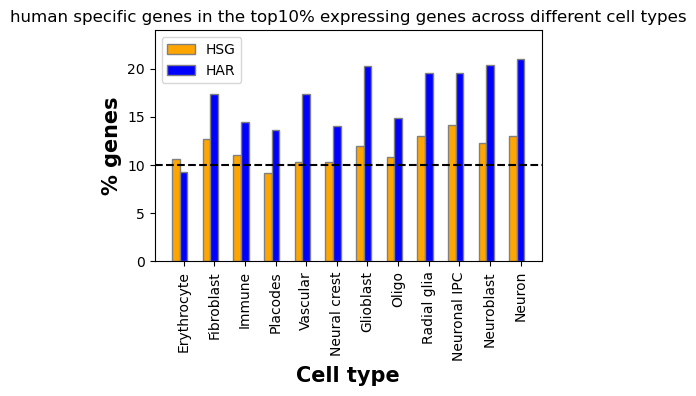

In [404]:
#graph
top_10_tot_df={'celltypes':cellclasses,'hsg_tot':[44,53,46,38,43,43,50,45,54,59,51,54],'har_tot':[78,146,121,114,146,118,170,125,164,164,171,176],
              'hsg_per':[10.576923076923077,12.740384615384615, 11.057692307692307, 9.134615384615383,10.336538461538462,10.336538461538462,
 12.01923076923077,10.817307692307693,12.980769230769232, 14.182692307692307, 12.259615384615383, 12.980769230769232],
               'har_per':[9.296781883194278,17.401668653158524,14.421930870083433,13.587604290822409,17.401668653158524,14.064362336114423,
 20.262216924910607,14.898688915375446,19.547079856972584,19.547079856972584,20.38140643623361,20.97735399284863]}

barWidth = 0.25
fig = plt2.subplots(figsize =(5, 3)) 

br1 = np.arange(12) 
br2 = [x + barWidth for x in br1] 

plt2.bar(br1,top_10_tot_df['hsg_per'], color ='orange', width = barWidth, 
        edgecolor ='grey', label ='HSG') 
plt2.bar(br2, top_10_tot_df['har_per'], color ='b', width = barWidth, 
        edgecolor ='grey', label ='HAR')
plt2.xticks([r + barWidth for r in range(12)], 
        ['Erythrocyte','Fibroblast','Immune','Placodes','Vascular','Neural crest','Glioblast','Oligo','Radial glia','Neuronal IPC','Neuroblast','Neuron'])
plt2.xticks(rotation=90)
plt2.title('human specific genes in the top10% expressing genes across different cell types')
plt2.ylabel('% genes', fontweight ='bold', fontsize = 15) 
plt2.xlabel('Cell type', fontweight ='bold', fontsize = 15) 
plt2.axhline(10, linestyle='--',color='black')
plt2.ylim(0,24)
plt2.legend()

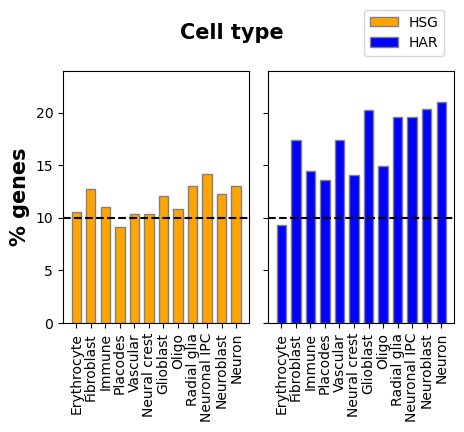

In [84]:
#separated_graph
hsg_per=[10.576923076923077,12.740384615384615, 11.057692307692307, 9.134615384615383,10.336538461538462,10.336538461538462,
 12.01923076923077,10.817307692307693,12.980769230769232, 14.182692307692307, 12.259615384615383, 12.980769230769232]
har_per=[9.296781883194278,17.401668653158524,14.421930870083433,13.587604290822409,17.401668653158524,14.064362336114423,
 20.262216924910607,14.898688915375446,19.547079856972584,19.547079856972584,20.38140643623361,20.97735399284863]
#fig, (ax1, ax2) = plt2.subplots(1, 2, figsize=(6, 4))
r1 = np.arange(0, 24, 2)
xticks_positions=np.arange(0, 24, 2)
fig, ax = plt2.subplots(1, 2,sharey=True,sharex=False,figsize=(5, 4))
#plt2.subplot(1, 2, 1)
ax[0].bar(r1,hsg_per, color ='orange', width=1.3, 
        edgecolor ='grey', label ='HSG')
ax[0].set_ylabel('% genes', fontweight ='bold', fontsize = 15) 
ax[0].axhline(10, linestyle='--',color='black')
ax[0].set_xticks(xticks_positions)
ax[0].set_xticklabels(['Erythrocyte','Fibroblast','Immune','Placodes','Vascular','Neural crest','Glioblast','Oligo','Radial glia','Neuronal IPC','Neuroblast','Neuron'],rotation=90)
ax[0].set_ylim(0,24)

#plt2.subplot(1, 2, 2)
ax[1].bar(r1,har_per, color ='b',  width=1.3,
        edgecolor ='grey', label ='HAR')
ax[1].set_xticks(xticks_positions)
ax[1].set_xticklabels(['Erythrocyte','Fibroblast','Immune','Placodes','Vascular','Neural crest','Glioblast','Oligo','Radial glia','Neuronal IPC','Neuroblast','Neuron'],rotation=90)
ax[1].axhline(10, linestyle='--',color='black')
ax[1].set_ylim(0,24)

# Adjust layout
plt2.tight_layout(pad=2.0)  # Add padding to avoid clipping
plt2.subplots_adjust(bottom=0.3)  # Increase bottom margin for x-ticks

plt2.suptitle('Cell type', fontsize=15,fontweight ='bold',y=1.05)
plt2.subplots_adjust(wspace=0.1)

fig.legend(loc='upper left', bbox_to_anchor=(0.75, 1.1), ncol=1)

plt2.show()

In [395]:
from scipy.stats import fisher_exact

def fisher_test_har(gene_exp,celltype,har_list,top10num):
    tot_genes=sum(gene_exp[celltype])
    har_genes2=sum(adata.var_names[gene_exp[celltype]].isin(har_list))
    table=np.array([[top10num,har_genes2-top10num],[int(tot_genes/10)-top10num,tot_genes-(int(tot_genes/10)-top10num)-(har_genes2-top10num)]])
    print(table)
    res = fisher_exact(table, alternative='greater')
    return res

def fisher_test_hsg(gene_exp,celltype,hsg_list,top10num):
    tot_genes=sum(gene_exp[celltype])
    hsg_genes2=sum(adata.var["Gene"][gene_exp[celltype]].isin(hsg_list))
    table=np.array([[top10num,hsg_genes2-top10num],[int(tot_genes/10)-top10num,tot_genes-(int(tot_genes/10)-top10num)-(hsg_genes2-top10num)]])
    print(table)
    res = fisher_exact(table, alternative='greater')
    return res

In [384]:
for i in range(len(celltypes)):
    print(cellclasses[i])
    print(fisher_test_har(gene_exp,cellclasses[i],har_exp_list,top_10_tot_df['har_tot'][i]))

Erythrocyte
[[   78   673]
 [ 2139 19365]]
SignificanceResult(statistic=np.float64(1.0492675820935335), pvalue=np.float64(0.36441445944731005))
Fibroblast
[[  146   693]
 [ 2824 26188]]
SignificanceResult(statistic=np.float64(1.953697231317628), pvalue=np.float64(1.2488874983721299e-11))
Immune
[[  121   697]
 [ 2566 23616]]
SignificanceResult(statistic=np.float64(1.5977259181147128), pvalue=np.float64(5.830886617005404e-06))
Placodes
[[  114   662]
 [ 2241 20654]]
SignificanceResult(statistic=np.float64(1.587117857128413), pvalue=np.float64(1.389090450449826e-05))
Vascular
[[  146   686]
 [ 2710 25165]]
SignificanceResult(statistic=np.float64(1.9763159876496723), pvalue=np.float64(6.3665303895436125e-12))
Neural crest
[[  118   671]
 [ 2281 21038]]
SignificanceResult(statistic=np.float64(1.6219544464705848), pvalue=np.float64(4.291222693116291e-06))
Glioblast
[[  170   669]
 [ 2936 27456]]
SignificanceResult(statistic=np.float64(2.3763150499138574), pvalue=np.float64(9.692412532367842

In [396]:
for i in range(len(celltypes)):
    print(cellclasses[i])
    print(fisher_test_hsg(gene_exp,cellclasses[i],gene_exp_list,top_10_tot_df['hsg_tot'][i]))

Erythrocyte
[[   44   261]
 [ 2173 19743]]
SignificanceResult(statistic=np.float64(1.5316713479431476), pvalue=np.float64(0.008116814493159699))
Fibroblast
[[   53   302]
 [ 2917 26486]]
SignificanceResult(statistic=np.float64(1.5934882749445476), pvalue=np.float64(0.001969464247031615))
Immune
[[   46   296]
 [ 2641 23942]]
SignificanceResult(statistic=np.float64(1.4088285559319258), pvalue=np.float64(0.022842826386849185))
Placodes
[[   38   298]
 [ 2317 20942]]
SignificanceResult(statistic=np.float64(1.1525491479667356), pvalue=np.float64(0.2302615791759078))
Vascular
[[   43   310]
 [ 2813 25438]]
SignificanceResult(statistic=np.float64(1.254353634622662), pvalue=np.float64(0.09985287725701886))
Neural crest
[[   43   291]
 [ 2356 21343]]
SignificanceResult(statistic=np.float64(1.3386148693983044), pvalue=np.float64(0.049901934602080034))
Glioblast
[[   50   305]
 [ 3056 27700]]
SignificanceResult(statistic=np.float64(1.4859239550253198), pvalue=np.float64(0.008197842530294158))
Ol

In [399]:
from scipy import stats
ps_hsg = [0.008116814493159699,0.001969464247031615,0.022842826386849185,0.2302615791759078,0.09985287725701886,0.049901934602080034,
     0.008197842530294158,0.04487030814469853,0.0011885455605823993,6.681251981327253e-05,0.005225234379364346,0.0011886980115009453]
stats.false_discovery_control(ps_hsg)

array([0.01405344, 0.00590839, 0.03426424, 0.23026158, 0.10893041,
       0.05988232, 0.01405344, 0.05982708, 0.00475479, 0.00080175,
       0.01254056, 0.00475479])

In [400]:
ps_har = [0.36441445944731005,1.2488874983721299e-11,5.830886617005404e-06,1.389090450449826e-05,6.3665303895436125e-12,4.291222693116291e-06,
     9.692412532367842e-20,1.2725561072612877e-06,1.67679008106531e-17,1.5885857043695154e-17,4.1482890051381595e-20,4.622170247574346e-22]
stats.false_discovery_control(ps_har)

array([3.64414459e-01, 2.14095000e-11, 6.99706394e-06, 1.51537140e-05,
       1.27330608e-11, 5.72163026e-06, 3.87696501e-19, 1.90883416e-06,
       4.02429619e-17, 4.02429619e-17, 2.48897340e-19, 5.54660430e-21])

In [405]:
uniqly_expressed=[]
for i in range(416):
    if sum(top10_ct_df.iloc[i,:12])==1:
        ct=celltypes[int(np.where(top10_ct_df.iloc[i,:12])[0])][2:-1]
        print(top10_ct_df["gene"][i],"gene expressed top uniquly in: ", ct)
        uniqly_expressed.append((top10_ct_df["gene"][i],ct))

SRGAP2B gene expressed top uniquly in:  Immune
FCGR3A gene expressed top uniquly in:  Immune
NEK2 gene expressed top uniquly in:  Neuronal IPC
ABCB10 gene expressed top uniquly in:  Erythrocyte
ESPN gene expressed top uniquly in:  Erythrocyte
TNFRSF1B gene expressed top uniquly in:  Immune
FCGR1B gene expressed top uniquly in:  Immune
SRGAP2C gene expressed top uniquly in:  Immune
PDE4DIP gene expressed top uniquly in:  Placodes
TMEM183A gene expressed top uniquly in:  Erythrocyte
CHRM3 gene expressed top uniquly in:  Oligo
MRC1 gene expressed top uniquly in:  Immune
CAPN1 gene expressed top uniquly in:  Erythrocyte
SLC6A13 gene expressed top uniquly in:  Fibroblast
KITLG gene expressed top uniquly in:  Vascular
RAB21 gene expressed top uniquly in:  Immune
PRKCH gene expressed top uniquly in:  Vascular
RGS6 gene expressed top uniquly in:  Erythrocyte
GOLGA8A gene expressed top uniquly in:  Oligo
CSPG4 gene expressed top uniquly in:  Vascular
ARHGAP11A gene expressed top uniquly in:  Ne

/tmp/ipykernel_1007100/2884793817.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ct=celltypes[int(np.where(top10_ct_df.iloc[i,:12])[0])][2:-1]


In [ ]:
#לצייר בוקספלוט

In [97]:
#do the same for tissues
tissuetypes=adata.obs.Tissue.unique().tolist()
p90_t={}
for i in tissuetypes:
    tissuetype=i[2:-1]
    p90_t[tissuetype]=np.percentile(adata.X[adata.obs.Tissue==i,:].mean(axis=0).A1,90)

In [98]:
p90_t

{'Cortex': np.float64(0.43855294463589967),
 'Hypothalamus': np.float64(0.2481227929547984),
 'Thalamus': np.float64(0.3940341660510306),
 'Ventral midbrain': np.float64(0.1988960722127421),
 'Forebrain cortex': np.float64(0.2224673752186155),
 'Subcortical forebrain': np.float64(0.6028754885539123),
 'Forebrain': np.float64(0.3371670989943007),
 'Cerebellum': np.float64(0.43637003264679497),
 'Dorsal midbrain': np.float64(0.37998741786654233),
 'Medulla': np.float64(0.2520713095792968),
 'Mesencephalon': np.float64(0.38821366768668664),
 'Pons/Cereb': np.float64(0.21885955712699204),
 'Tel/diencephalon': np.float64(0.38971717773146675),
 'Diencephalon': np.float64(0.27872414291910697),
 'Pons': np.float64(0.30411811548271617),
 'Striatum': np.float64(0.28578032114063745),
 'Telencephalon': np.float64(0.31269143505388136),
 'Hindbrain': np.float64(0.7981028325621545),
 'Head': np.float64(1.2906579533640028),
 'Pons/Medulla': np.float64(0.3384273326910358),
 'Subcortex': np.float64(0.58

In [101]:
exp_df_tissue=exp_df_tissue.drop(columns=['Unnamed: 0'])

In [104]:
exp_df_tissue

,per_exp_Cortex,mean_exp_Cortex,per_exp_Hypothalamus,mean_exp_Hypothalamus,per_exp_Thalamus,mean_exp_Thalamus,per_exp_Ventral_midbrain,mean_exp_Ventral_midbrain,per_exp_Forebrain_cortex,mean_exp_Forebrain_cortex,...,mean_exp_Occipital_cortex,per_exp_Upper_cortex,mean_exp_Upper_cortex,per_exp_Caudate-Putamen,mean_exp_Caudate-Putamen,per_exp_Brain,mean_exp_Brain,per_exp_Midbrain,mean_exp_Midbrain,gene
0,0.000541,0.000575,0.000325,0.000390,0.000584,0.000611,0.000061,0.000061,0.000269,0.000269,...,0.000750,0.000668,0.000668,0.000531,0.000531,0.001279,0.001407,0.000657,0.000717,TNFRSF9
1,0.121154,0.143369,0.071449,0.078056,0.105590,0.122664,0.038790,0.042144,0.085968,0.092560,...,0.310270,0.266939,0.334026,0.324960,0.458147,0.216054,0.267684,0.137423,0.165212,NBPF1
2,0.213643,0.297003,0.152755,0.189042,0.205042,0.284364,0.111979,0.139851,0.130365,0.148796,...,0.590180,0.440594,0.723711,0.306291,0.520149,0.478784,0.823796,0.276639,0.422190,KIAA0319L
3,0.055117,0.068817,0.044152,0.053034,0.070448,0.091672,0.019334,0.020554,0.032019,0.037064,...,0.084483,0.186494,0.264861,0.064658,0.094483,0.258451,0.488889,0.075211,0.101386,RAB3B
4,0.040634,0.058752,0.077233,0.102515,0.186007,0.414781,0.018480,0.020066,0.057716,0.074398,...,0.109820,0.151243,0.318145,0.182211,0.511725,0.263998,0.779155,0.099116,0.205582,MIR137HG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,0.004144,0.004905,0.002101,0.002426,0.003794,0.004168,0.001464,0.001586,0.001480,0.001547,...,0.011769,0.008609,0.009870,0.007134,0.009259,0.008919,0.010779,0.005169,0.005857,SPANXA2-OT1
412,0.044049,0.045446,0.021426,0.021968,0.030573,0.031521,0.021469,0.022201,0.029194,0.029598,...,0.071139,0.090983,0.096549,0.039159,0.039766,0.071526,0.074677,0.034453,0.035887,CXorf40A
413,0.013981,0.015057,0.006824,0.006998,0.009212,0.009659,0.005123,0.005550,0.006996,0.006996,...,0.051574,0.060037,0.065751,0.027700,0.031570,0.033117,0.036676,0.016405,0.018168,SPRY3
414,0.082645,0.090377,0.054702,0.059143,0.084530,0.093542,0.047268,0.051598,0.047895,0.050652,...,0.153223,0.158219,0.190501,0.090688,0.111179,0.185530,0.224578,0.100430,0.121048,VAMP7


In [ ]:
#לעשות אחוזים של ביטוי כמה גנים שהם רק human מתבטאים מתוך כל התאים לנרמל..

In [406]:
#do the same for region
p90_r={}
gene_exp_r={}
for i in regions:
    region=i[2:-1]
    print(region)
    r_data=adata.X[adata.obs.Region==i,:]
    gene_exp_r[region]=genes_expressed_total[adata.obs.Region==i,:].sum(axis=0)>0
    p90_r[region]=np.percentile(r_data[:,gene_exp_r[region]].mean(axis=0).A1,90)

Head
Brain
Forebrain
Midbrain
Hindbrain
Telencephalon
Diencephalon
Cerebellum
Medulla
Pons


In [407]:
p90_r

{'Head': np.float64(1.4289469775731258),
 'Brain': np.float64(1.0604253636753043),
 'Forebrain': np.float64(0.4384761123163406),
 'Midbrain': np.float64(0.4179485270204675),
 'Hindbrain': np.float64(0.7249072112397504),
 'Telencephalon': np.float64(0.5232756915564529),
 'Diencephalon': np.float64(0.34530086938222276),
 'Cerebellum': np.float64(0.445996566475502),
 'Medulla': np.float64(0.2634254178542893),
 'Pons': np.float64(0.2857458959390833)}

In [178]:
#p90_r from before
p90_r

{'Head': np.float64(1.2906579533640028),
 'Brain': np.float64(1.0353675128200266),
 'Forebrain': np.float64(0.43268748056470774),
 'Midbrain': np.float64(0.41215262400948804),
 'Hindbrain': np.float64(0.7019210857479317),
 'Telencephalon': np.float64(0.5184856308730427),
 'Diencephalon': np.float64(0.3377128148554594),
 'Cerebellum': np.float64(0.43637003264679497),
 'Medulla': np.float64(0.2520713095792968),
 'Pons': np.float64(0.274239774092233)}

In [212]:
exp_df_region=exp_df_region.drop(columns='Unnamed: 0')

In [408]:
top10_r={}
regions2=adata.obs.Region.unique().tolist()
for i in range(len(regions2)):
    ind=i*2+1
    for j in exp_df_region["gene"]:
        r=regions2[i][2:-1]
        exp=float(exp_df_region.iloc[np.where(exp_df_region["gene"]==j)[0],ind])
        if r not in top10_r:
            top10_r[r]=[bool(exp>=p90_r[r])]
        else:
            top10_r[r].append(bool(exp>=p90_r[r]))

/tmp/ipykernel_1007100/3843505798.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exp=float(exp_df_region.iloc[np.where(exp_df_region["gene"]==j)[0],ind])


In [409]:
top10_r_df=pd.DataFrame.from_dict(top10_r)
top10_r_df["gene"]=exp_df_region["gene"]
top10_r_df

,Telencephalon,Diencephalon,Midbrain,Forebrain,Cerebellum,Medulla,Pons,Hindbrain,Head,Brain,gene
0,False,False,False,False,False,False,False,False,False,False,TNFRSF9
1,False,False,False,False,False,False,False,False,False,False,NBPF1
2,False,False,False,False,False,False,False,False,False,False,KIAA0319L
3,False,False,False,False,False,False,False,False,False,False,RAB3B
4,False,False,False,False,False,False,False,False,False,False,MIR137HG
...,...,...,...,...,...,...,...,...,...,...,...
411,False,False,False,False,False,False,False,False,False,False,SPANXA2-OT1
412,False,False,False,False,False,False,False,False,False,False,CXorf40A
413,False,False,False,False,False,False,False,False,False,False,SPRY3
414,False,False,False,False,False,False,False,False,False,False,VAMP7


In [410]:
print(top10_r_df.columns[:-1])
print([sum(top10_r_df[i].tolist()) for i in top10_r_df.columns[:-1]])

Index(['Telencephalon', 'Diencephalon', 'Midbrain', 'Forebrain', 'Cerebellum',
       'Medulla', 'Pons', 'Hindbrain', 'Head', 'Brain'],
      dtype='object')
[59, 51, 51, 53, 51, 44, 48, 50, 47, 56]


In [234]:
adata.obs.Region.unique().tolist()

["b'Telencephalon'",
 "b'Diencephalon'",
 "b'Midbrain'",
 "b'Forebrain'",
 "b'Cerebellum'",
 "b'Medulla'",
 "b'Pons'",
 "b'Hindbrain'",
 "b'Head'",
 "b'Brain'"]

In [411]:
top10_r_har={}
regions2=adata.obs.Region.unique().tolist()
for i in range(len(regions2)):
    ind=i*2+1
    for j in exp_df_region_har["ens"]:
        r=regions2[i][2:-1]
        exp=float(exp_df_region_har.iloc[np.where(exp_df_region_har["ens"]==j)[0],ind])
        if r not in top10_r_har:
            top10_r_har[r]=[bool(exp>=p90_r[r])]
        else:
            top10_r_har[r].append(bool(exp>=p90_r[r]))

/tmp/ipykernel_1007100/3167272096.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exp=float(exp_df_region_har.iloc[np.where(exp_df_region_har["ens"]==j)[0],ind])


In [412]:
top10_r_har_df=pd.DataFrame.from_dict(top10_r_har)
top10_r_har_df["ens"]=exp_df_region_har["ens"]
top10_r_har_df

,Telencephalon,Diencephalon,Midbrain,Forebrain,Cerebellum,Medulla,Pons,Hindbrain,Head,Brain,ens
0,False,False,False,False,False,False,False,False,False,False,ENSG00000177133
1,False,False,False,False,False,False,False,False,False,False,ENSG00000007923
2,False,False,False,False,False,False,False,False,False,False,ENSG00000237728
3,True,True,True,True,True,True,True,True,True,True,ENSG00000142599
4,False,False,False,False,False,False,False,False,False,False,ENSG00000130940
...,...,...,...,...,...,...,...,...,...,...,...
834,False,False,False,False,False,False,False,False,False,False,ENSG00000169239
835,False,False,False,False,False,False,False,False,False,False,ENSG00000086717
836,False,False,False,False,False,False,False,False,False,False,ENSG00000015285
837,False,False,False,False,False,False,False,False,False,False,ENSG00000101945


In [413]:
print(top10_r_har_df.columns[:-1])
print([sum(top10_r_har_df[i].tolist()) for i in top10_r_har_df.columns[:-1]])

Index(['Telencephalon', 'Diencephalon', 'Midbrain', 'Forebrain', 'Cerebellum',
       'Medulla', 'Pons', 'Hindbrain', 'Head', 'Brain'],
      dtype='object')
[174, 155, 161, 163, 169, 147, 146, 168, 143, 171]


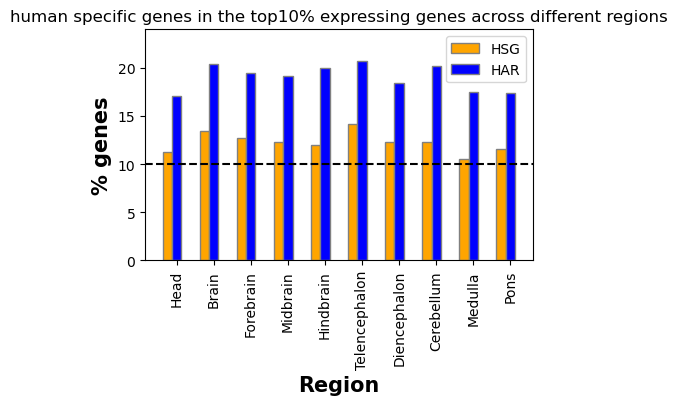

In [423]:
region_hsg_per=[(i/416)*100 for i in [47,56,53,51,50,59,51, 51, 44, 48]]
region_har_per=[(i/839)*100 for i in [143,171,163,161,168,174,155,169, 147, 146]]

barWidth = 0.25
fig = plt2.subplots(figsize =(5, 3)) 

br1 = np.arange(10) 
br2 = [x + barWidth for x in br1] 

plt2.bar(br1,region_hsg_per, color ='orange', width = barWidth, 
        edgecolor ='grey', label ='HSG') 
plt2.bar(br2, region_har_per, color ='b', width = barWidth, 
        edgecolor ='grey', label ='HAR')
plt2.xticks([r + barWidth for r in range(10)], 
        ['Head', 'Brain', 'Forebrain', 'Midbrain', 'Hindbrain', 'Telencephalon',
       'Diencephalon', 'Cerebellum', 'Medulla', 'Pons'])
plt2.xticks(rotation=90)
plt2.title('human specific genes in the top10% expressing genes across different regions')
plt2.ylabel('% genes', fontweight ='bold', fontsize = 15) 
plt2.xlabel('Region', fontweight ='bold', fontsize = 15)
plt2.axhline(10, linestyle='--',color='black')
plt2.ylim(0,24)
plt2.legend()

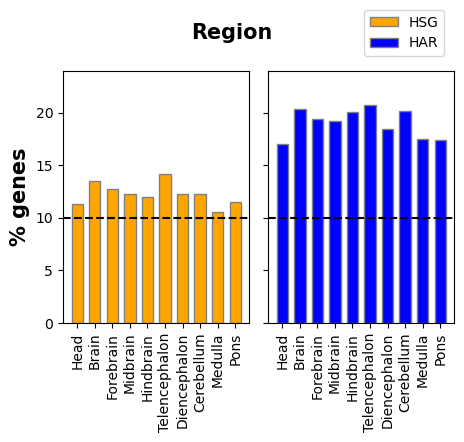

In [83]:
#separate plots
region_hsg_per=[(i/416)*100 for i in [47,56,53,51,50,59,51, 51, 44, 48]]
region_har_per=[(i/839)*100 for i in [143,171,163,161,168,174,155,169, 147, 146]]
r1 = np.arange(0, 20, 2)
xticks_positions=np.arange(0, 20, 2)
fig, ax = plt2.subplots(1, 2,sharey=True,sharex=False,figsize=(5, 4))
#plt2.subplot(1, 2, 1)
ax[0].bar(r1,region_hsg_per, color ='orange', width=1.3, 
        edgecolor ='grey', label ='HSG')
ax[0].set_ylabel('% genes', fontweight ='bold', fontsize = 15) 
ax[0].axhline(10, linestyle='--',color='black')
ax[0].set_xticks(xticks_positions)
ax[0].set_xticklabels( ['Head', 'Brain', 'Forebrain', 'Midbrain', 'Hindbrain', 'Telencephalon',
       'Diencephalon', 'Cerebellum', 'Medulla', 'Pons'],rotation=90)
ax[0].set_ylim(0,24)

#plt2.subplot(1, 2, 2)
ax[1].bar(r1,region_har_per, color ='b',  width=1.3,
        edgecolor ='grey', label ='HAR')
ax[1].set_xticks(xticks_positions)
ax[1].set_xticklabels( ['Head', 'Brain', 'Forebrain', 'Midbrain', 'Hindbrain', 'Telencephalon',
       'Diencephalon', 'Cerebellum', 'Medulla', 'Pons'],rotation=90)
ax[1].axhline(10, linestyle='--',color='black')
ax[1].set_ylim(0,24)

# Adjust layout
plt2.tight_layout(pad=2.0)  # Add padding to avoid clipping
plt2.subplots_adjust(bottom=0.3)  # Increase bottom margin for x-ticks

plt2.suptitle('Region', fontsize=15,fontweight ='bold',y=1.05)
plt2.subplots_adjust(wspace=0.1)

fig.legend(loc='upper left', bbox_to_anchor=(0.75, 1.1), ncol=1)

plt2.show()

In [419]:
regions_c= ['Head', 'Brain', 'Forebrain', 'Midbrain', 'Hindbrain', 'Telencephalon',
       'Diencephalon', 'Cerebellum', 'Medulla', 'Pons']
hsg_tot2=[47,56,53,51,50,59,51, 51, 44, 48]
for i in range(10):
    print(regions_c[i])
    print(fisher_test_hsg(gene_exp_r,regions_c[i],gene_exp_list,hsg_tot2[i]))

Head
[[   47   305]
 [ 2820 25545]]
SignificanceResult(statistic=np.float64(1.3959016393442623), pvalue=np.float64(0.024469957673382857))
Brain
[[   56   298]
 [ 3056 27766]]
SignificanceResult(statistic=np.float64(1.7073860641624794), pvalue=np.float64(0.00037167113078163353))
Forebrain
[[   53   302]
 [ 3099 28119]]
SignificanceResult(statistic=np.float64(1.5923818621260009), pvalue=np.float64(0.0019878177042400944))
Midbrain
[[   51   304]
 [ 3106 28166]]
SignificanceResult(statistic=np.float64(1.5213190937743586), pvalue=np.float64(0.0052071126430545895))
Hindbrain
[[   50   305]
 [ 3045 27602]]
SignificanceResult(statistic=np.float64(1.4860157743142481), pvalue=np.float64(0.008190991410907185))
Telencephalon
[[   59   296]
 [ 3108 28273]]
SignificanceResult(statistic=np.float64(1.813222851229608), pvalue=np.float64(6.677221176534409e-05))
Diencephalon
[[   51   304]
 [ 3079 27925]]
SignificanceResult(statistic=np.float64(1.5215284781456728), pvalue=np.float64(0.005197154142896851)

In [421]:
ps_hsg = [0.024469957673382857,0.00037167113078163353,0.0019878177042400944,0.0052071126430545895,0.008190991410907185,6.677221176534409e-05,
     0.005197154142896851,0.005222042731418695,0.07865590036070605,0.0189361846868746]
stats.false_discovery_control(ps_hsg)

array([0.02718884, 0.00185836, 0.00662606, 0.0087034 , 0.01170142,
       0.00066772, 0.0087034 , 0.0087034 , 0.0786559 , 0.02367023])

In [420]:
har_tot2=[143,171,163,161,168,174,155,169, 147, 146]
for i in range(10):
    print(regions_c[i])
    print(fisher_test_har(gene_exp_r,regions_c[i],har_exp_list,har_tot2[i]))

Head
[[  143   690]
 [ 2724 25256]]
SignificanceResult(statistic=np.float64(1.921517802038775), pvalue=np.float64(5.408893691022009e-11))
Brain
[[  171   668]
 [ 2941 27511]]
SignificanceResult(statistic=np.float64(2.394589094507347), pvalue=np.float64(4.048690568336174e-20))
Forebrain
[[  163   676]
 [ 2989 27855]]
SignificanceResult(statistic=np.float64(2.2470780435561557), pvalue=np.float64(3.7956535107064886e-17))
Midbrain
[[  161   678]
 [ 2996 27902]]
SignificanceResult(statistic=np.float64(2.2115140738290187), pvalue=np.float64(1.9016178649587324e-16))
Hindbrain
[[  168   671]
 [ 2927 27354]]
SignificanceResult(statistic=np.float64(2.3398331073509038), pvalue=np.float64(5.451262950505848e-19))
Telencephalon
[[  174   665]
 [ 2993 28019]]
SignificanceResult(statistic=np.float64(2.4494778543418354), pvalue=np.float64(2.7998872608207142e-21))
Diencephalon
[[  155   684]
 [ 2975 27649]]
SignificanceResult(statistic=np.float64(2.106046980195587), pvalue=np.float64(2.0255932437273713e

In [ ]:
#check genes across tissues or cell types:
#define top10% for each tiisue or cell type
#mark true if gene is in the top 10% or not..

In [251]:
celltypes

["b'Erythrocyte'",
 "b'Fibroblast'",
 "b'Glioblast'",
 "b'Immune'",
 "b'Neuroblast'",
 "b'Neural crest'",
 "b'Neuron'",
 "b'Neuronal IPC'",
 "b'Oligo'",
 "b'Radial glia'",
 "b'Placodes'",
 "b'Vascular'"]

In [260]:
len(adata.X[adata.obs.CellClass=="b'Immune'",].toarray())

8101

In [265]:
for i in range(8101):
    print(i)
    print(np.percentile(adata.X[adata.obs.CellClass=="b'Immune'",].toarray()[i],90))

0
0.0
1
0.0
2
0.0
3
0.0
4
1.0
5
0.0
6
0.0
7
0.0
8
1.0
9
1.0
10
0.0
11
0.0
12
0.0
13
0.0
14
0.0
15
0.0
16
0.0
17
1.0
18
0.0
19
1.0
20
1.0
21
0.0
22
0.0
23
0.0
24
0.0
25
0.0
26
0.0
27
0.0
28
0.0
29
0.0
30
0.0
31
0.0
32
0.0
33
0.0
34
0.0
35
0.0
36
0.0
37
0.0
38
0.0
39
0.0
40
0.0
41
0.0
42
0.0
43
0.0
44
0.0
45
0.0
46
0.0
47
0.0
48
0.0
49
0.0
50
0.0
51
0.0
52
0.0
53
0.0
54
0.0
55
0.0
56
0.0
57
0.0
58
0.0
59
0.0
60
0.0
61
0.0
62
0.0
63
0.0
64
0.0
65
0.0
66
0.0
67
0.0
68
0.0
69
0.0
70
0.0
71
0.0
72
0.0
73
0.0
74
0.0
75
0.0
76
0.0
77
0.0
78
0.0
79
0.0
80
0.0
81
0.0
82
0.0
83
0.0
84
0.0
85
0.0
86
0.0
87
0.0
88
0.0
89
0.0
90
0.0
91
0.0
92
0.0
93
0.0
94
0.0
95
0.0
96
0.0
97
0.0
98
0.0
99
0.0
100
0.0
101
0.0
102
0.0
103
0.0
104
0.0
105
0.0
106
0.0
107
0.0
108
0.0
109
0.0
110
0.0
111
0.0
112
0.0
113
0.0
114
0.0
115
0.0
116
0.0
117
0.0
118
0.0
119
0.0
120
0.0
121
0.0
122
0.0
123
0.0
124
0.0
125
0.0
126
0.0
127
0.0
128
0.0
129
0.0
130
0.0
131
0.0
132
0.0
133
0.0
134
0.0
135
0.0
136
0.0
137
0.0
138
0.

KeyboardInterrupt: 

In [ ]:
for i in gene_exp_list:
    for ct in celltypes:
        ct_data=adata.X[adata.obs.CellClass==ct,].
        gene_exp=adata.X[adata.obs.CellClass==ct,adata
        